In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
sys.path.append('../../map/')
from map import *

In [4]:
with open('../../Prediction/MTR/output/challenge/mtr+validation_data_withmap6_train_split_derivheading/default/eval/epoch_no_number/default/result.pkl', 'rb') as file:
        derivheading_fromscratch = pickle.load(file)
with open('/home/tianhui/Intersection_Safety_Challenge_Prediction/Prediction/MTR/output/challenge/mtr+val+ann_data_withmap_h1s/val_ann_h1s_cluster64/eval/eval_with_train/result.pkl', 'rb') as file:
        val_ann_h1s_cluster64 = pickle.load(file)
with open('/home/tianhui/Intersection_Safety_Challenge_Prediction/Prediction/MTR/output/challenge/mtr+val+ann_data_withmap_h1s_cluster32/val_ann_h1s_cluster32/eval/eval_with_train/result.pkl', 'rb') as file:
        val_ann_h1s_cluster32 = pickle.load(file)
with open('/home/tianhui/Intersection_Safety_Challenge_Prediction/Prediction/MTR/output/challenge/mtr+val+ann12_data_withmap_h1s_cluster32/val_ann12_h1s_cluster32/eval/eval_with_train/result.pkl', 'rb') as file:
        val_ann12_h1s_cluster32 = pickle.load(file)

In [ ]:
# basic plotting, only plot the traj
def plot_traj(sample_id, traj_id, data, vector_map, mode):

    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']

    for i in range(mode):
        pred_traj_i = pred_traj[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]
        # print(x_coords.shape)
        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        

        plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

    plt.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=1)
    plt.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=1)

    plt.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)

    plt.show()

In [ ]:
# plot traj with map
def plot_traj_withmap(sample_id, traj_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True




    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']

    for i in range(mode):
        pred_traj_i = pred_traj[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]

        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])

        ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


    ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=1)
    ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=1)

    ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)

    ax.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [11]:
# plot with traj,map and heading (after optimization)
def plot_traj_withmap_withheading(sample_id, traj_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True


    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']
    pred_scores = data[sample_id][traj_id]['pred_scores']
    top3_indices = np.argsort(pred_scores)[-mode:][::-1]
    top3_scores = pred_scores[top3_indices]
    top3_pred_trajs = pred_traj[top3_indices]
    normalized_top3_scores = top3_scores / np.sum(top3_scores)

    for i in range(mode):
        pred_traj_i = top3_pred_trajs[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]

        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        
        ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='Red', markersize=0.5, alpha = 0.5)
        ax.annotate(f'{normalized_top3_scores[i]:.4f}', 
                xy=(x_coords[-1], y_coords[-1]),  # Position at the end of the trajectory
                textcoords="offset points", 
                xytext=(5,5), 
                ha='center', 
                color='Blue')
        # ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


    # for i in range(mode):
    #     pred_traj_i = pred_traj[i]
    #     x_coords = pred_traj_i[:, 0]
    #     y_coords = pred_traj_i[:, 1]

    #     x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
    #     y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        
    #     # print(i, top3_indices)
    #     ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

    ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=0.5, alpha = 0.5)
    ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=0.5, alpha = 0.5)

    ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)
    ax.quiver(gt_traj[10][0], gt_traj[10][1], np.cos(gt_traj[10][6]),np.sin(gt_traj[10][6]), color='orange',scale = 0.1,angles='xy',scale_units='xy',width=0.006, alpha = 0.3)


    ax.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [5]:
with open("../../map/vector_map.pkl", "rb") as f:
    vector_map = pickle.load(f)

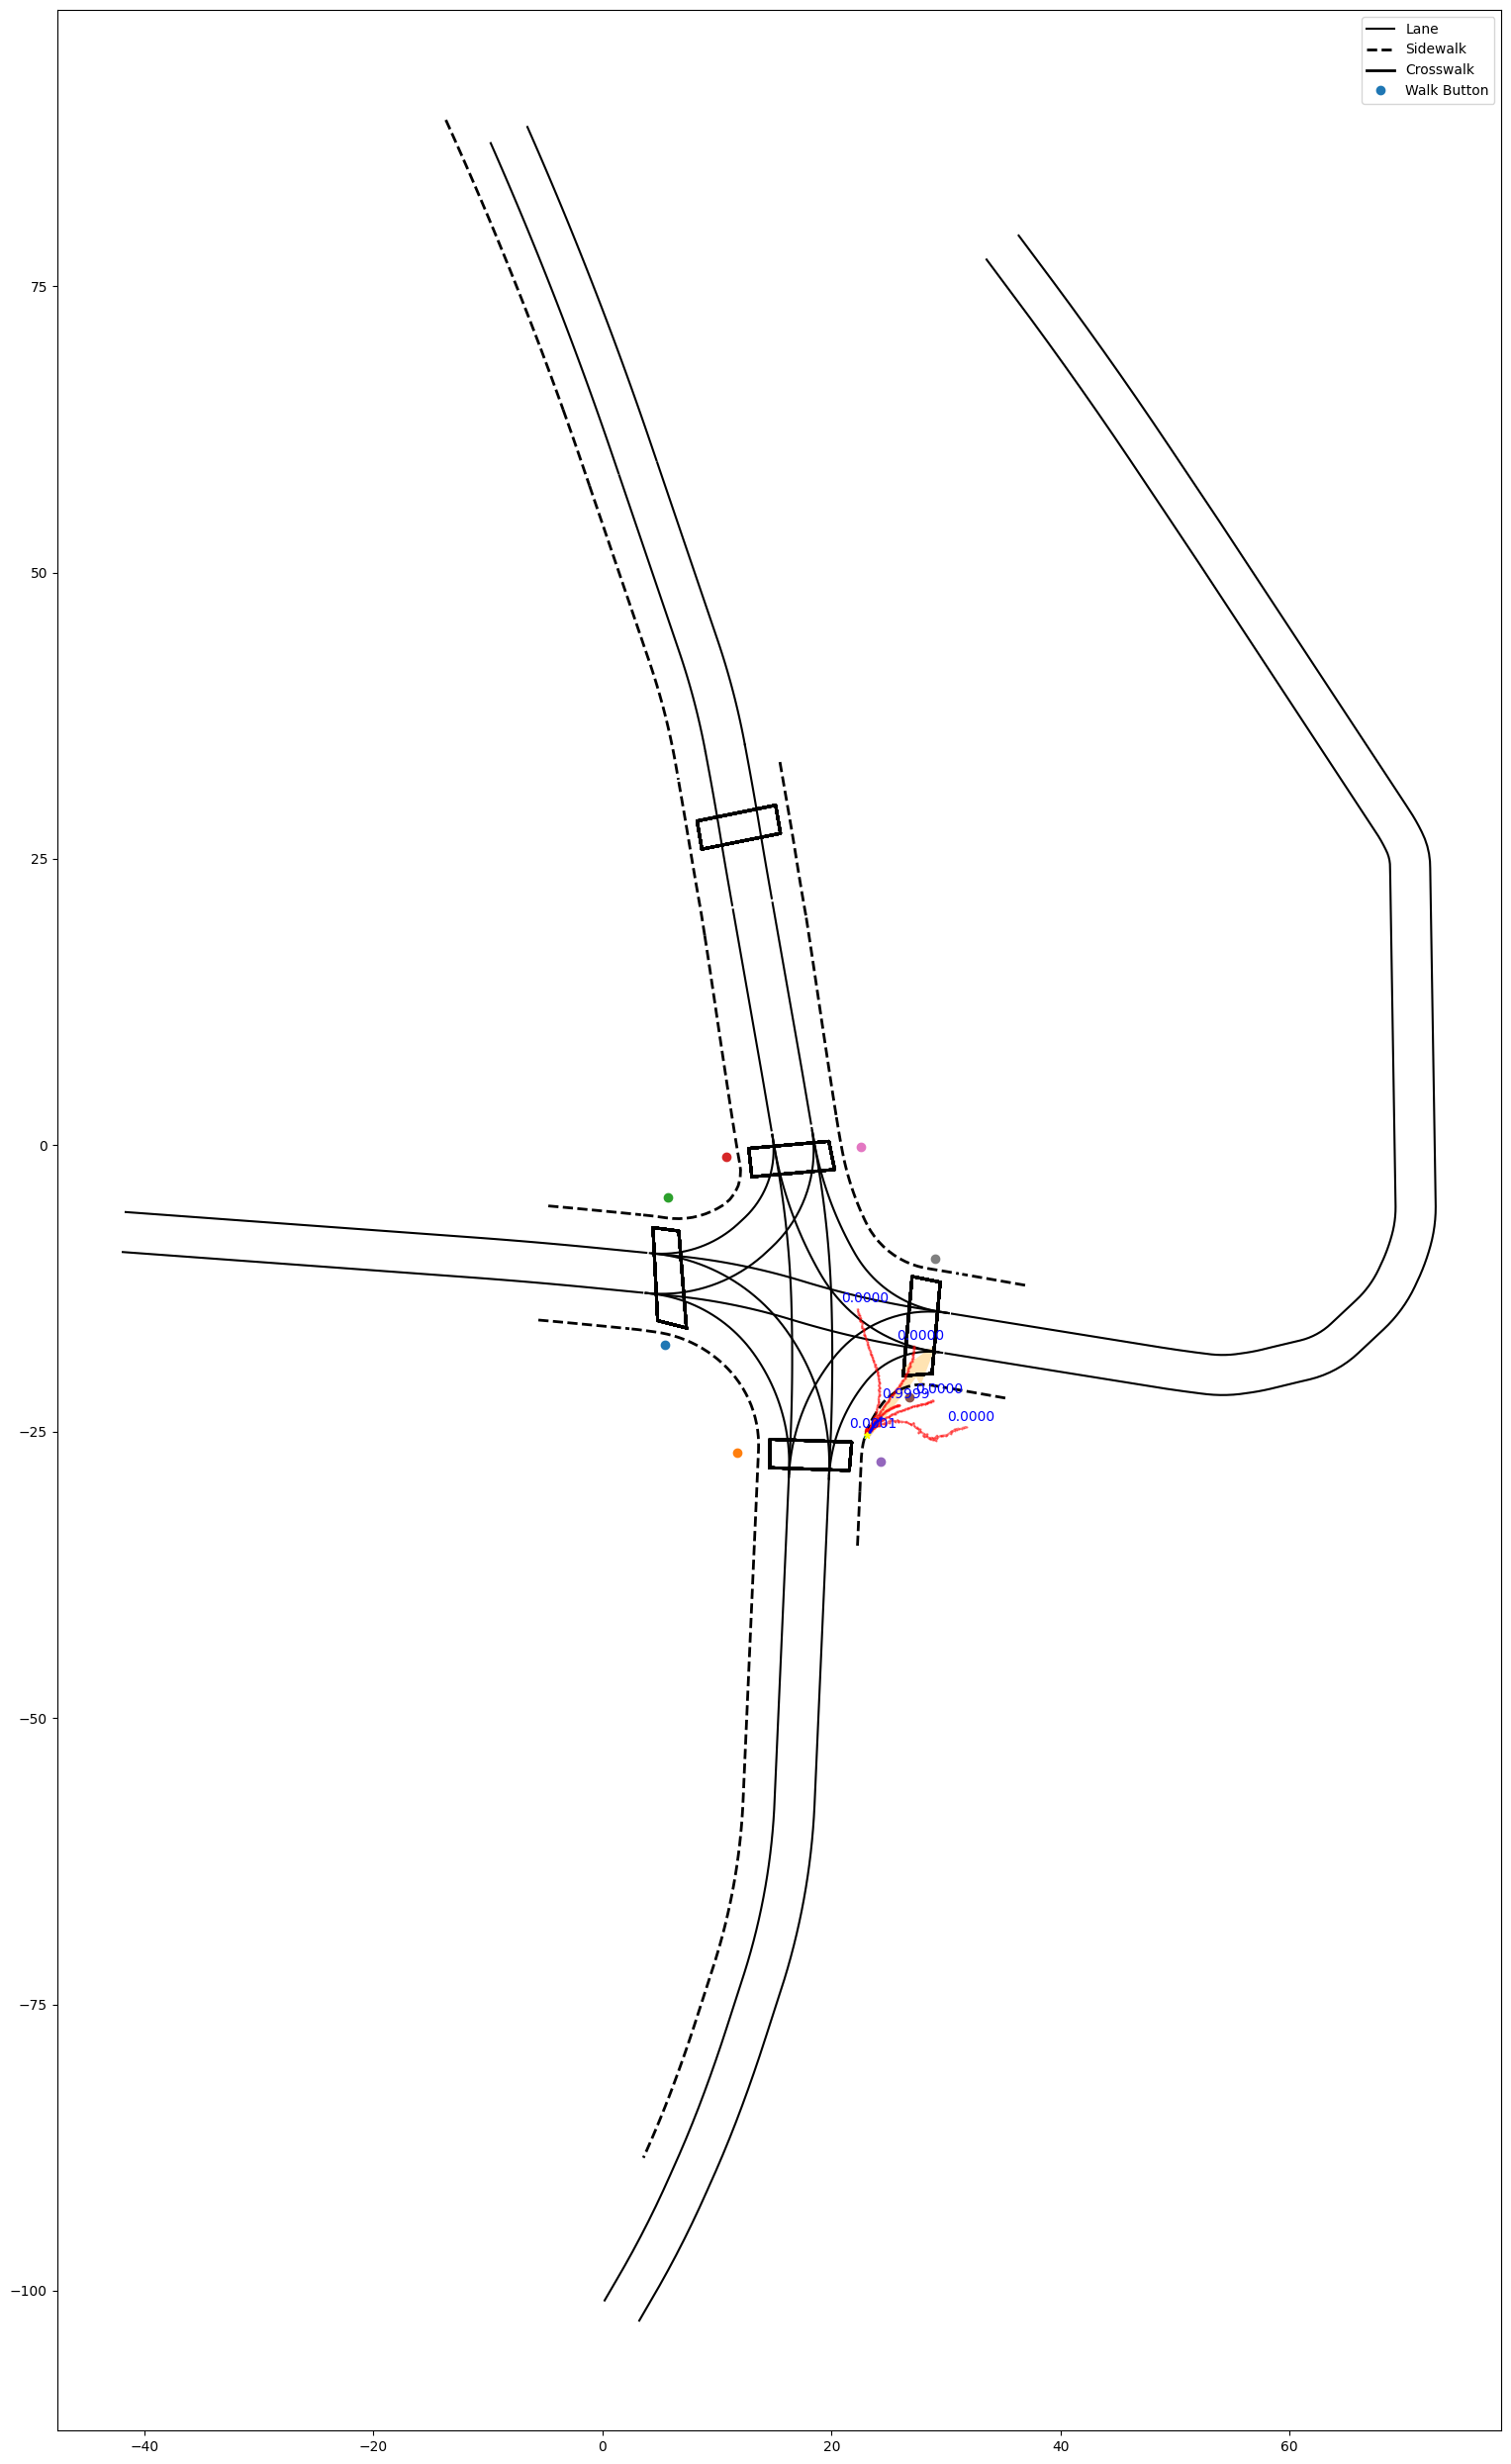

----------------------------------------------------


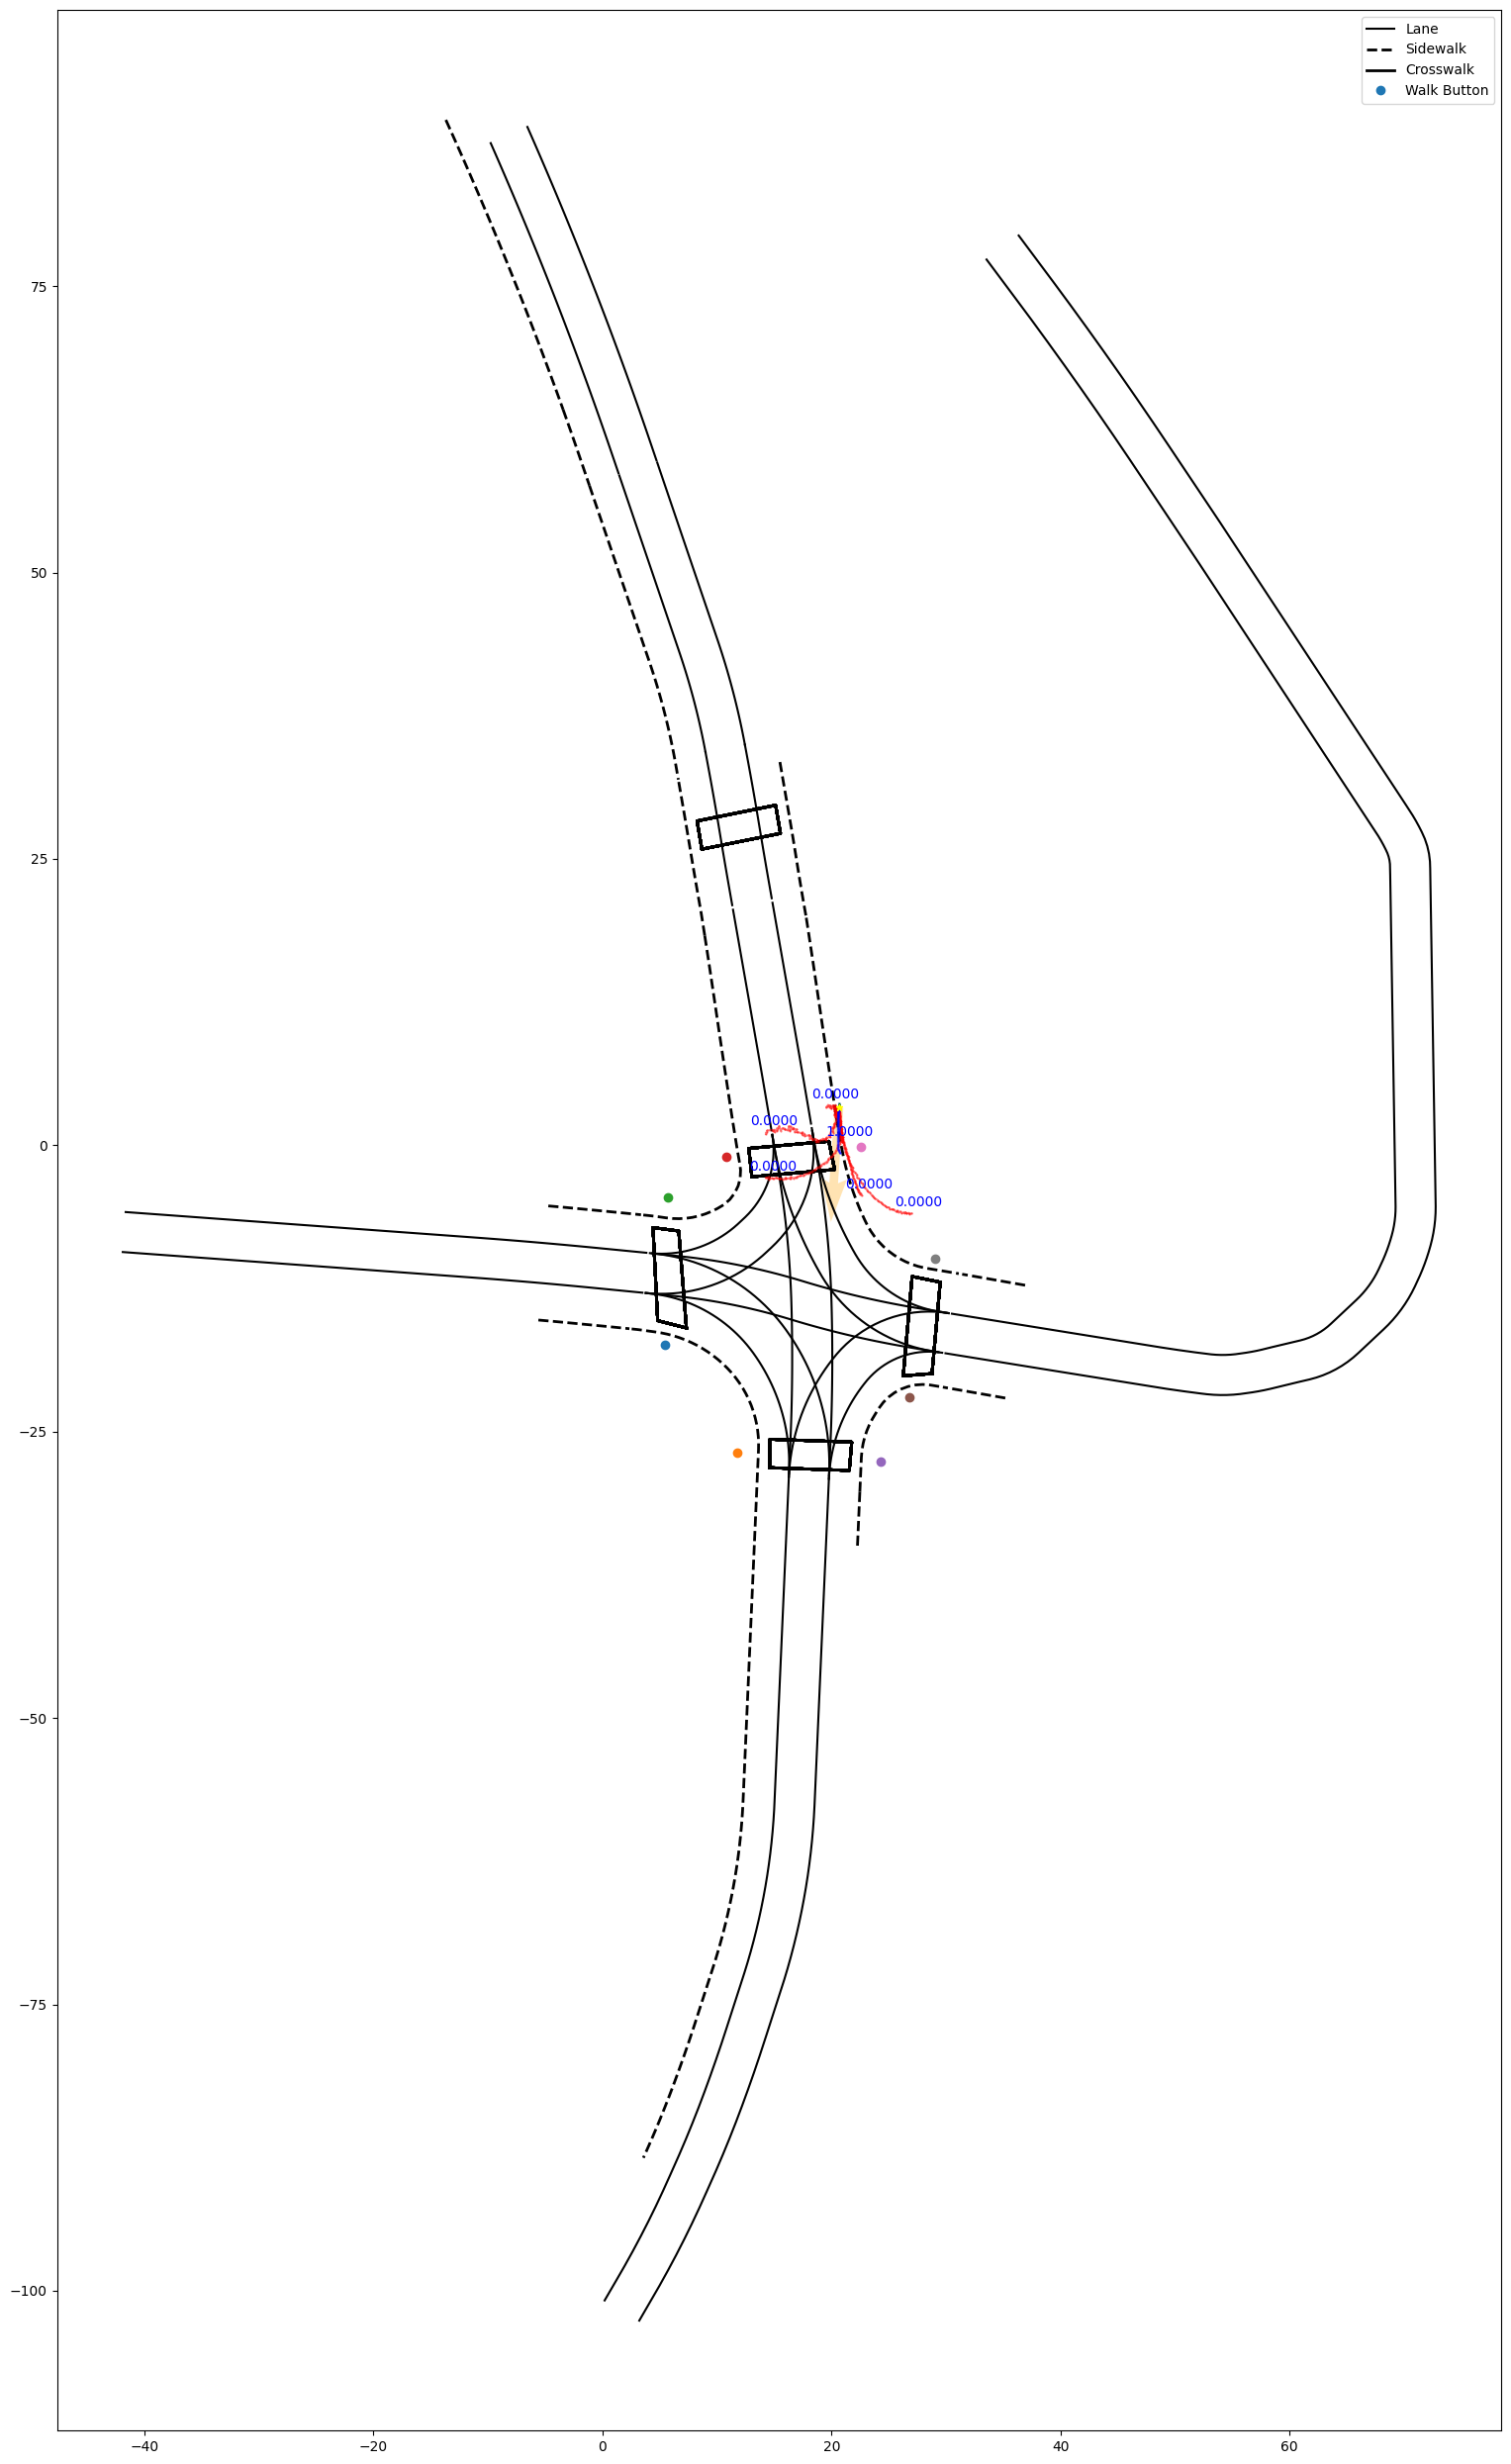

----------------------------------------------------


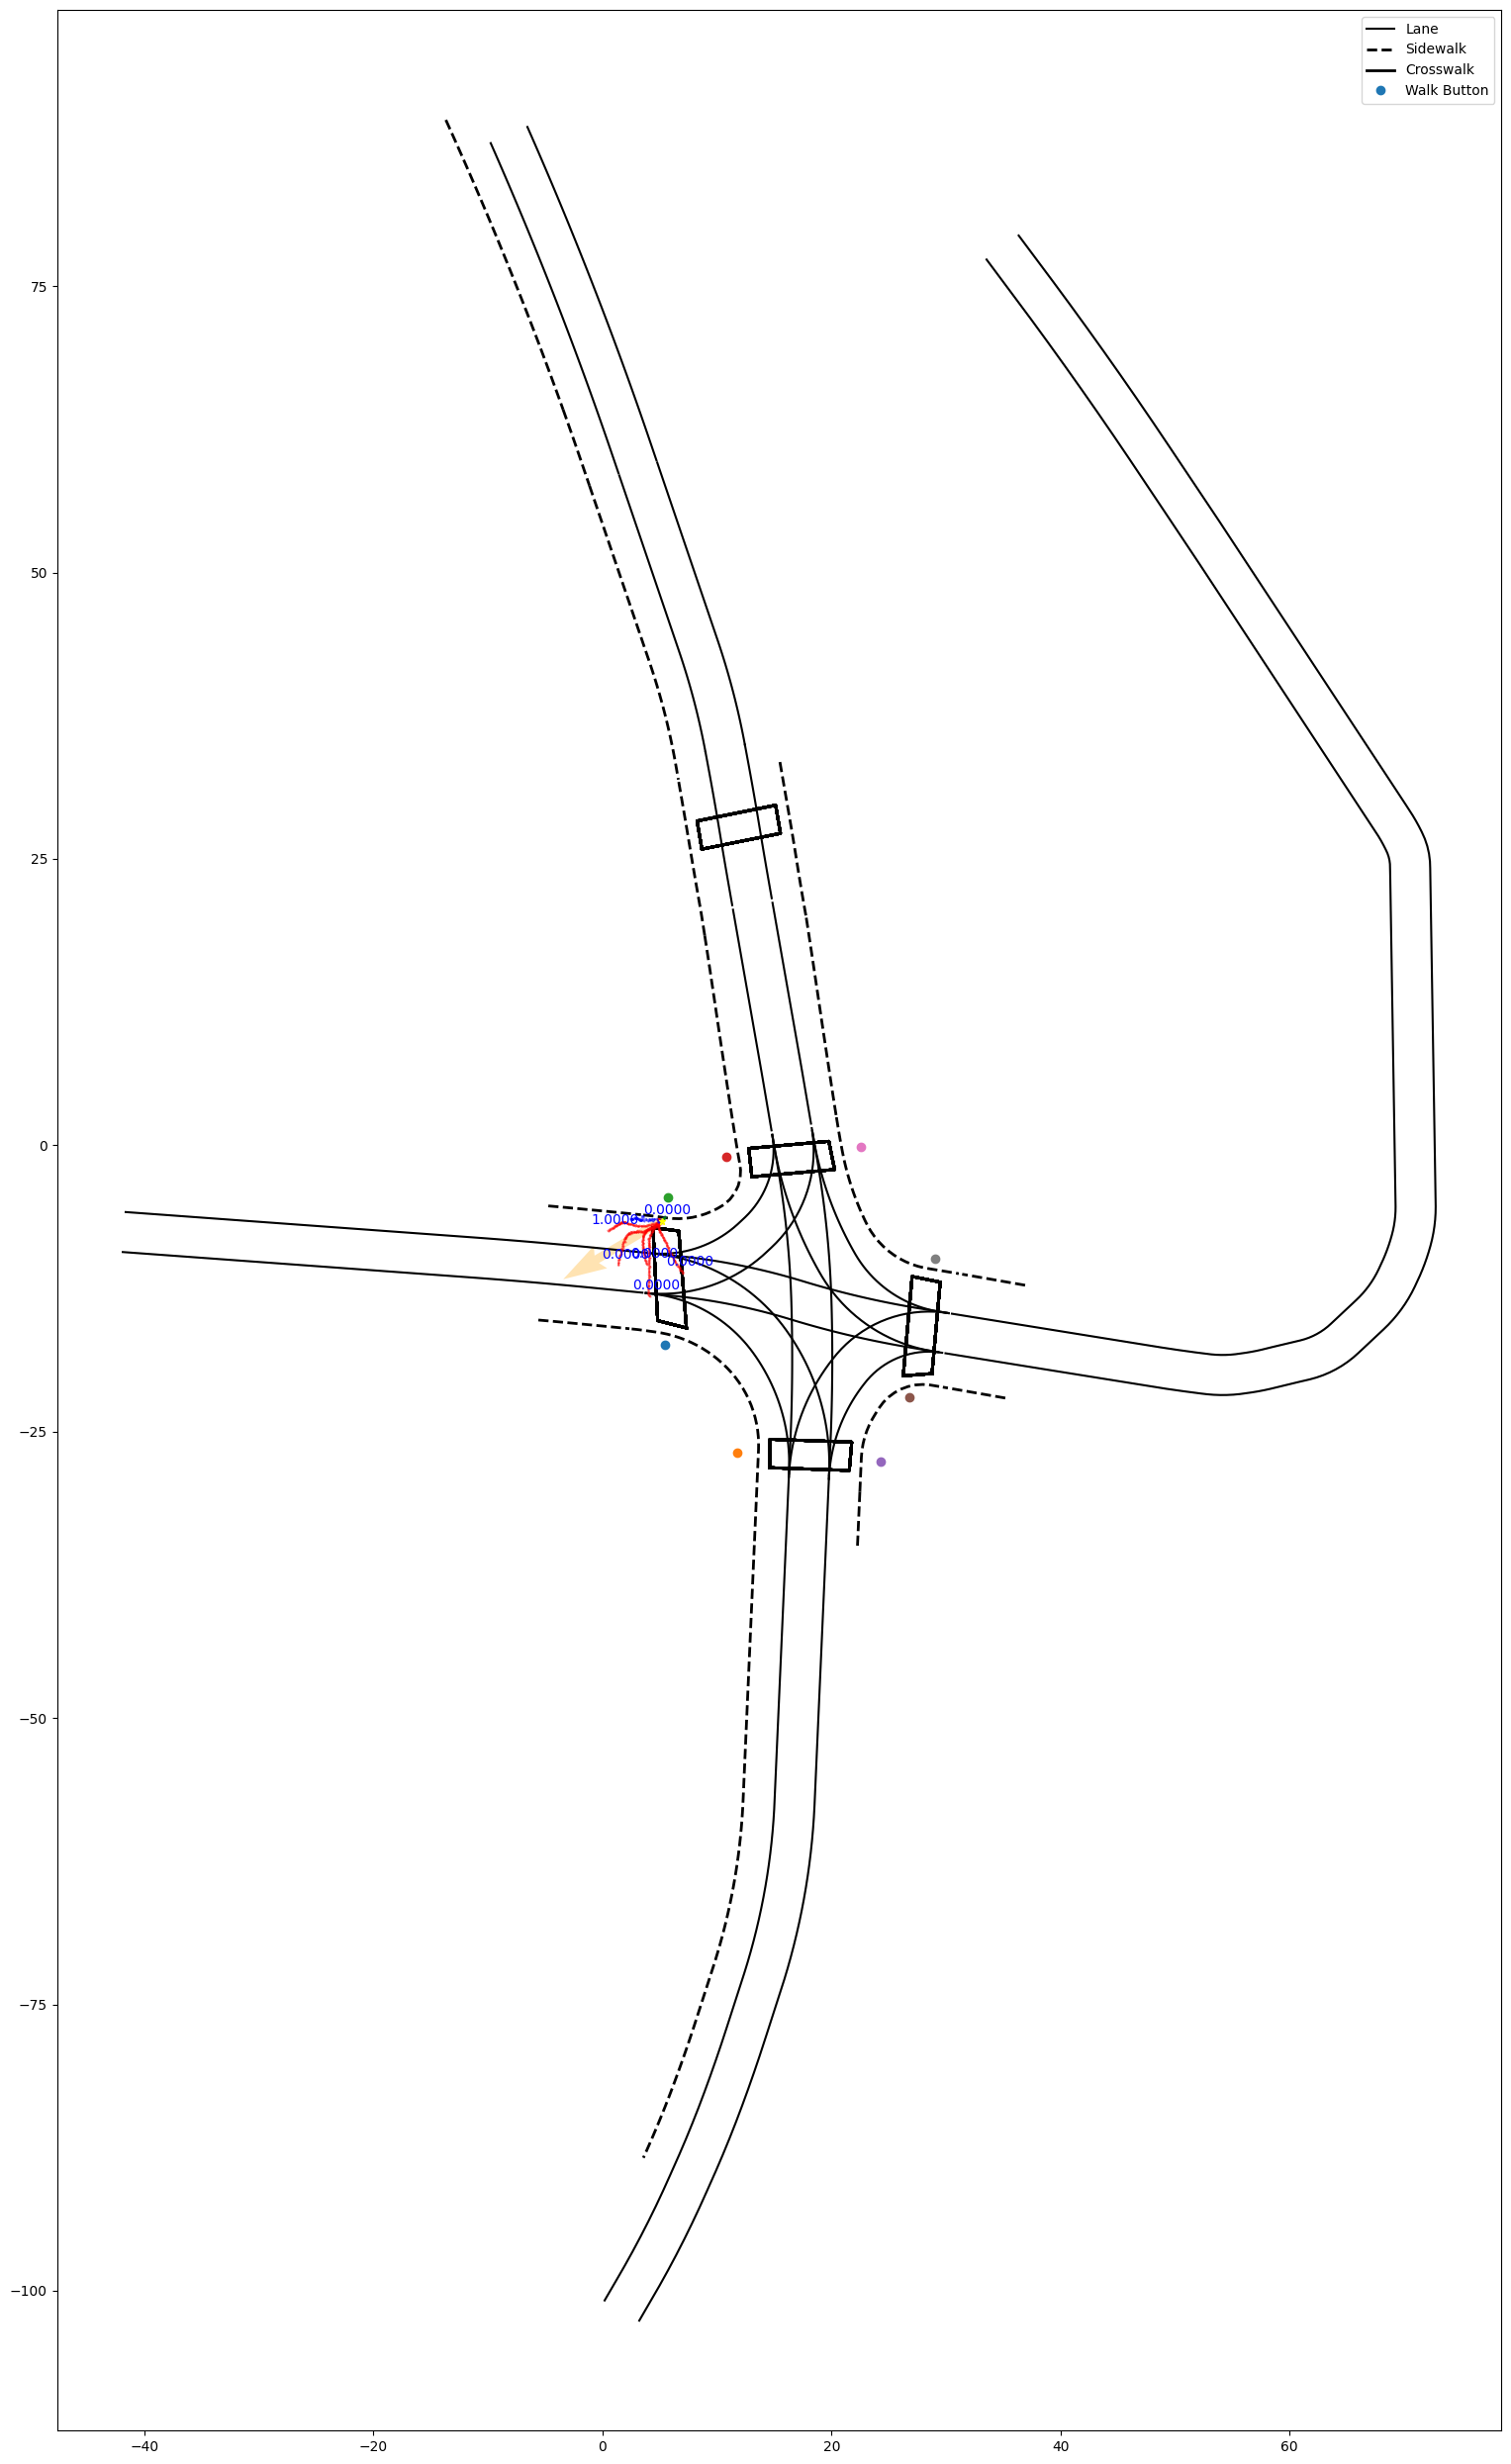

----------------------------------------------------


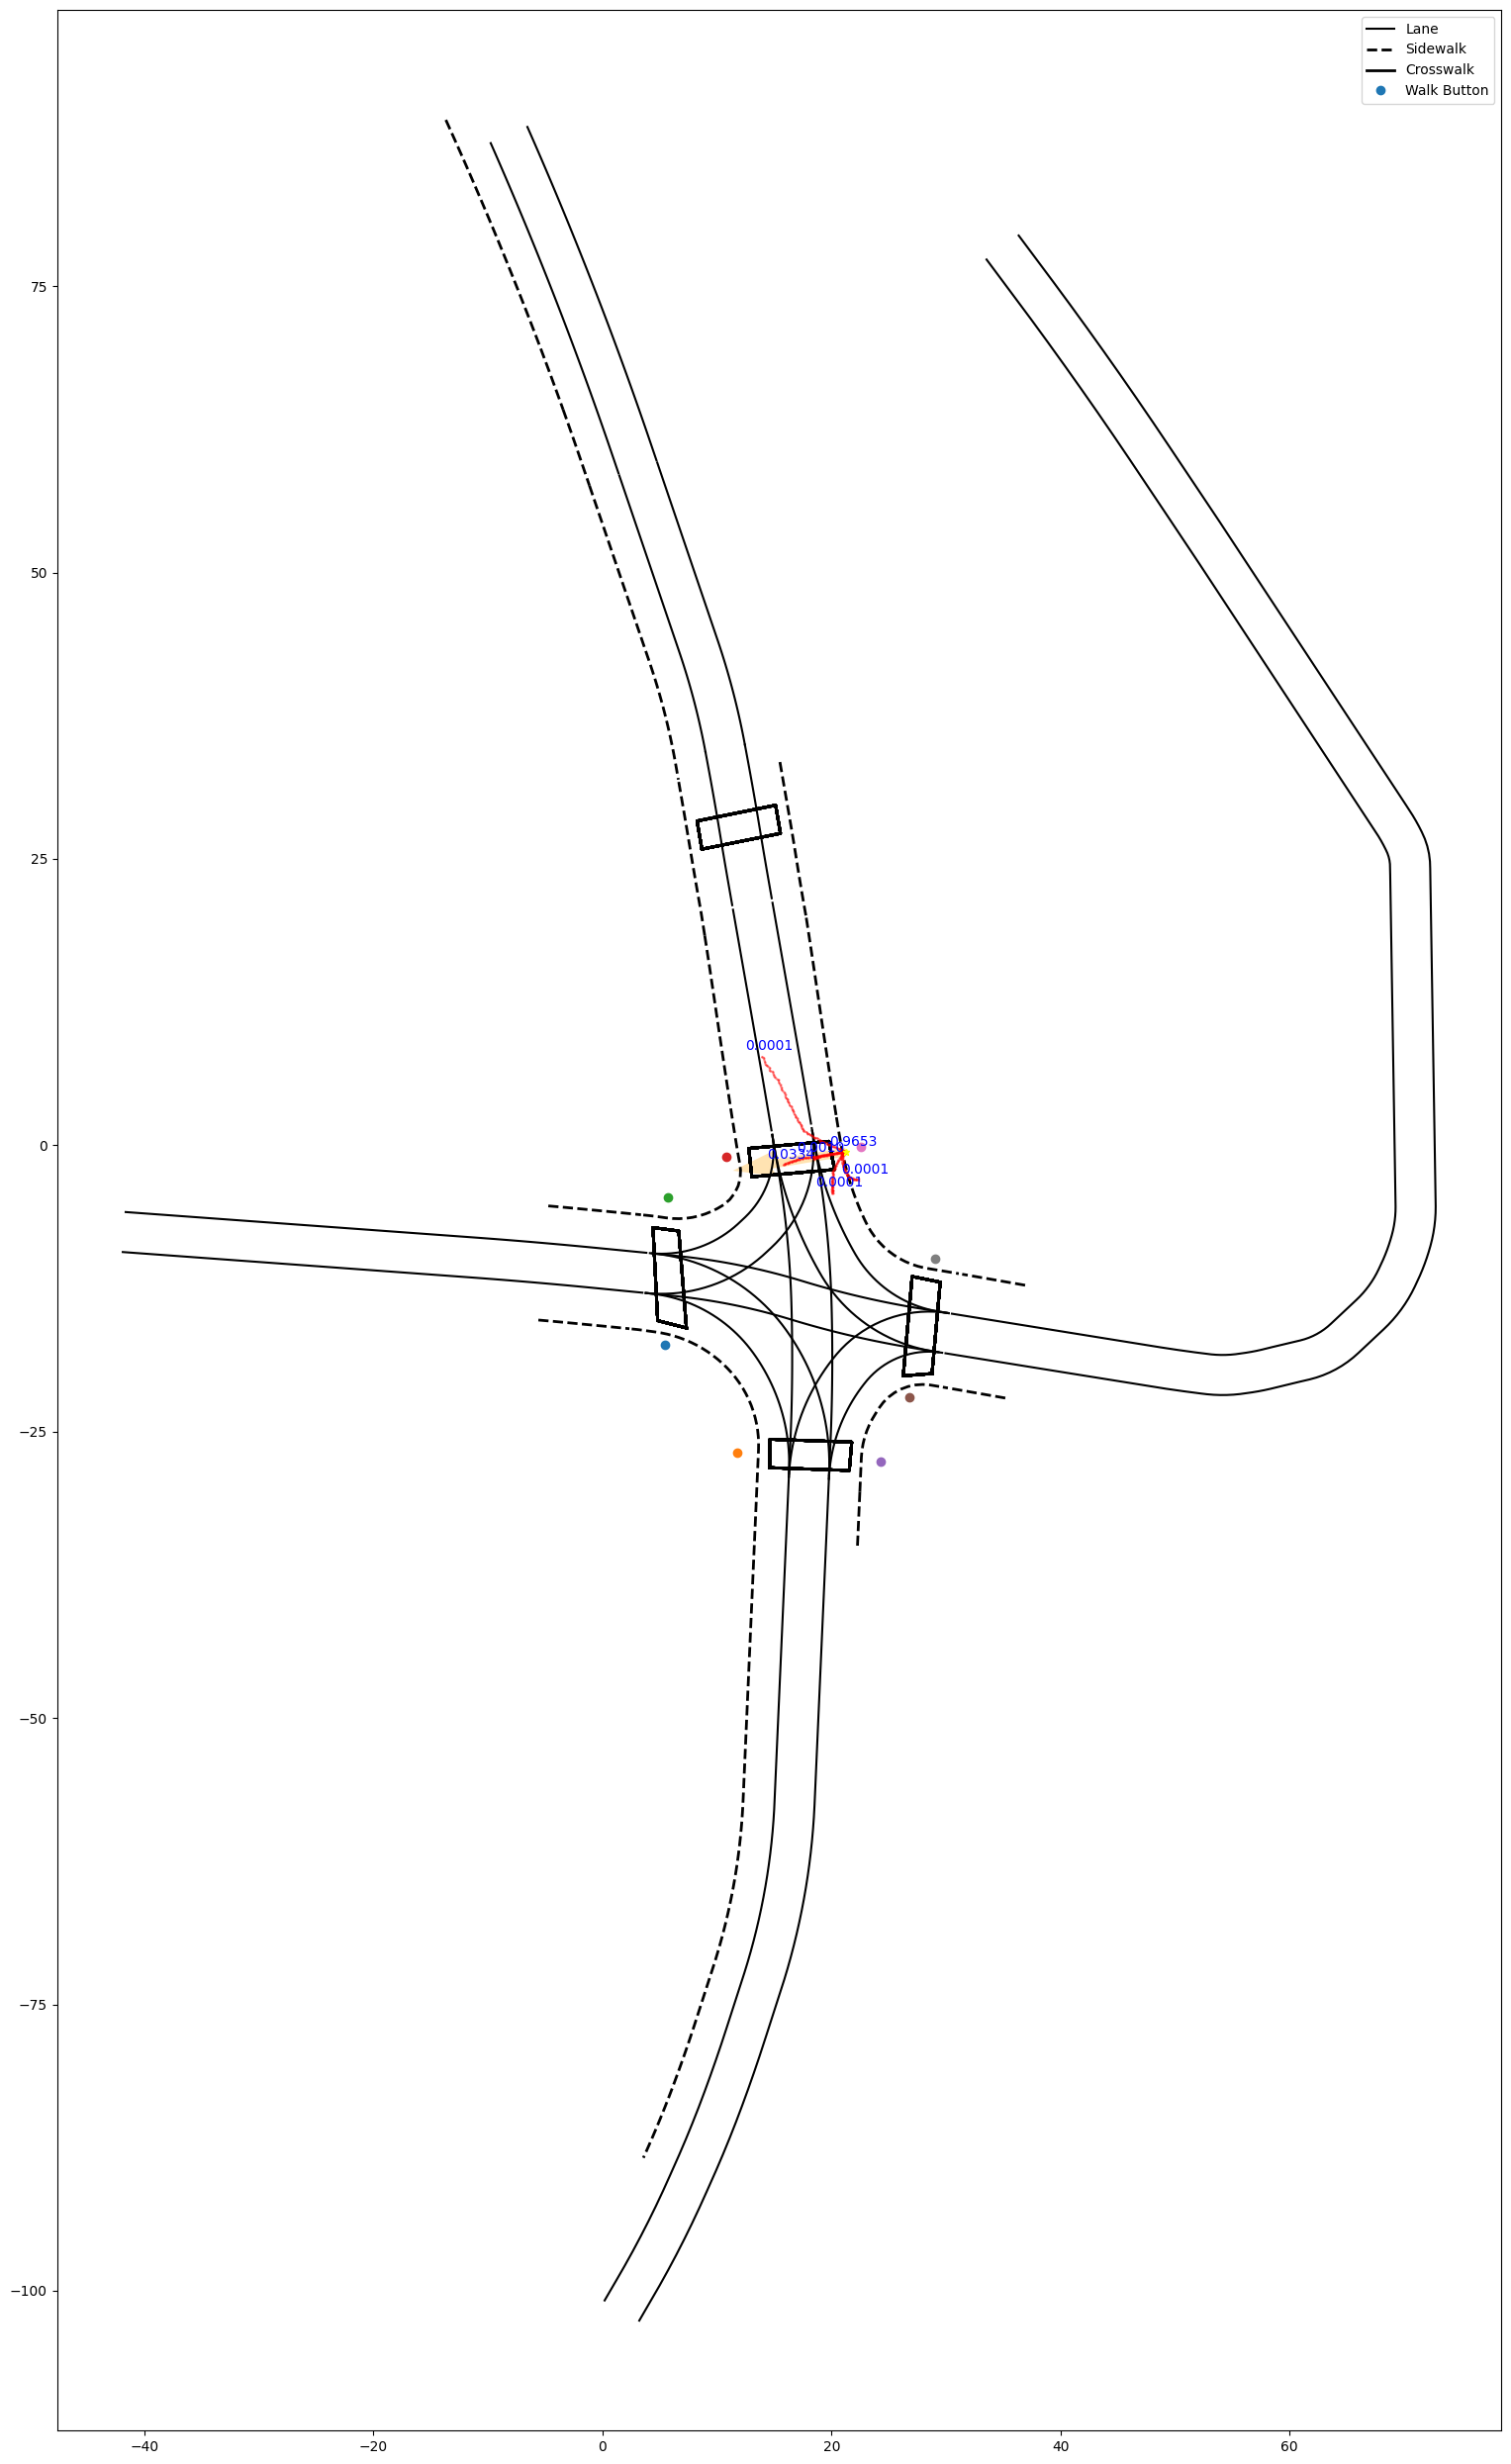

----------------------------------------------------


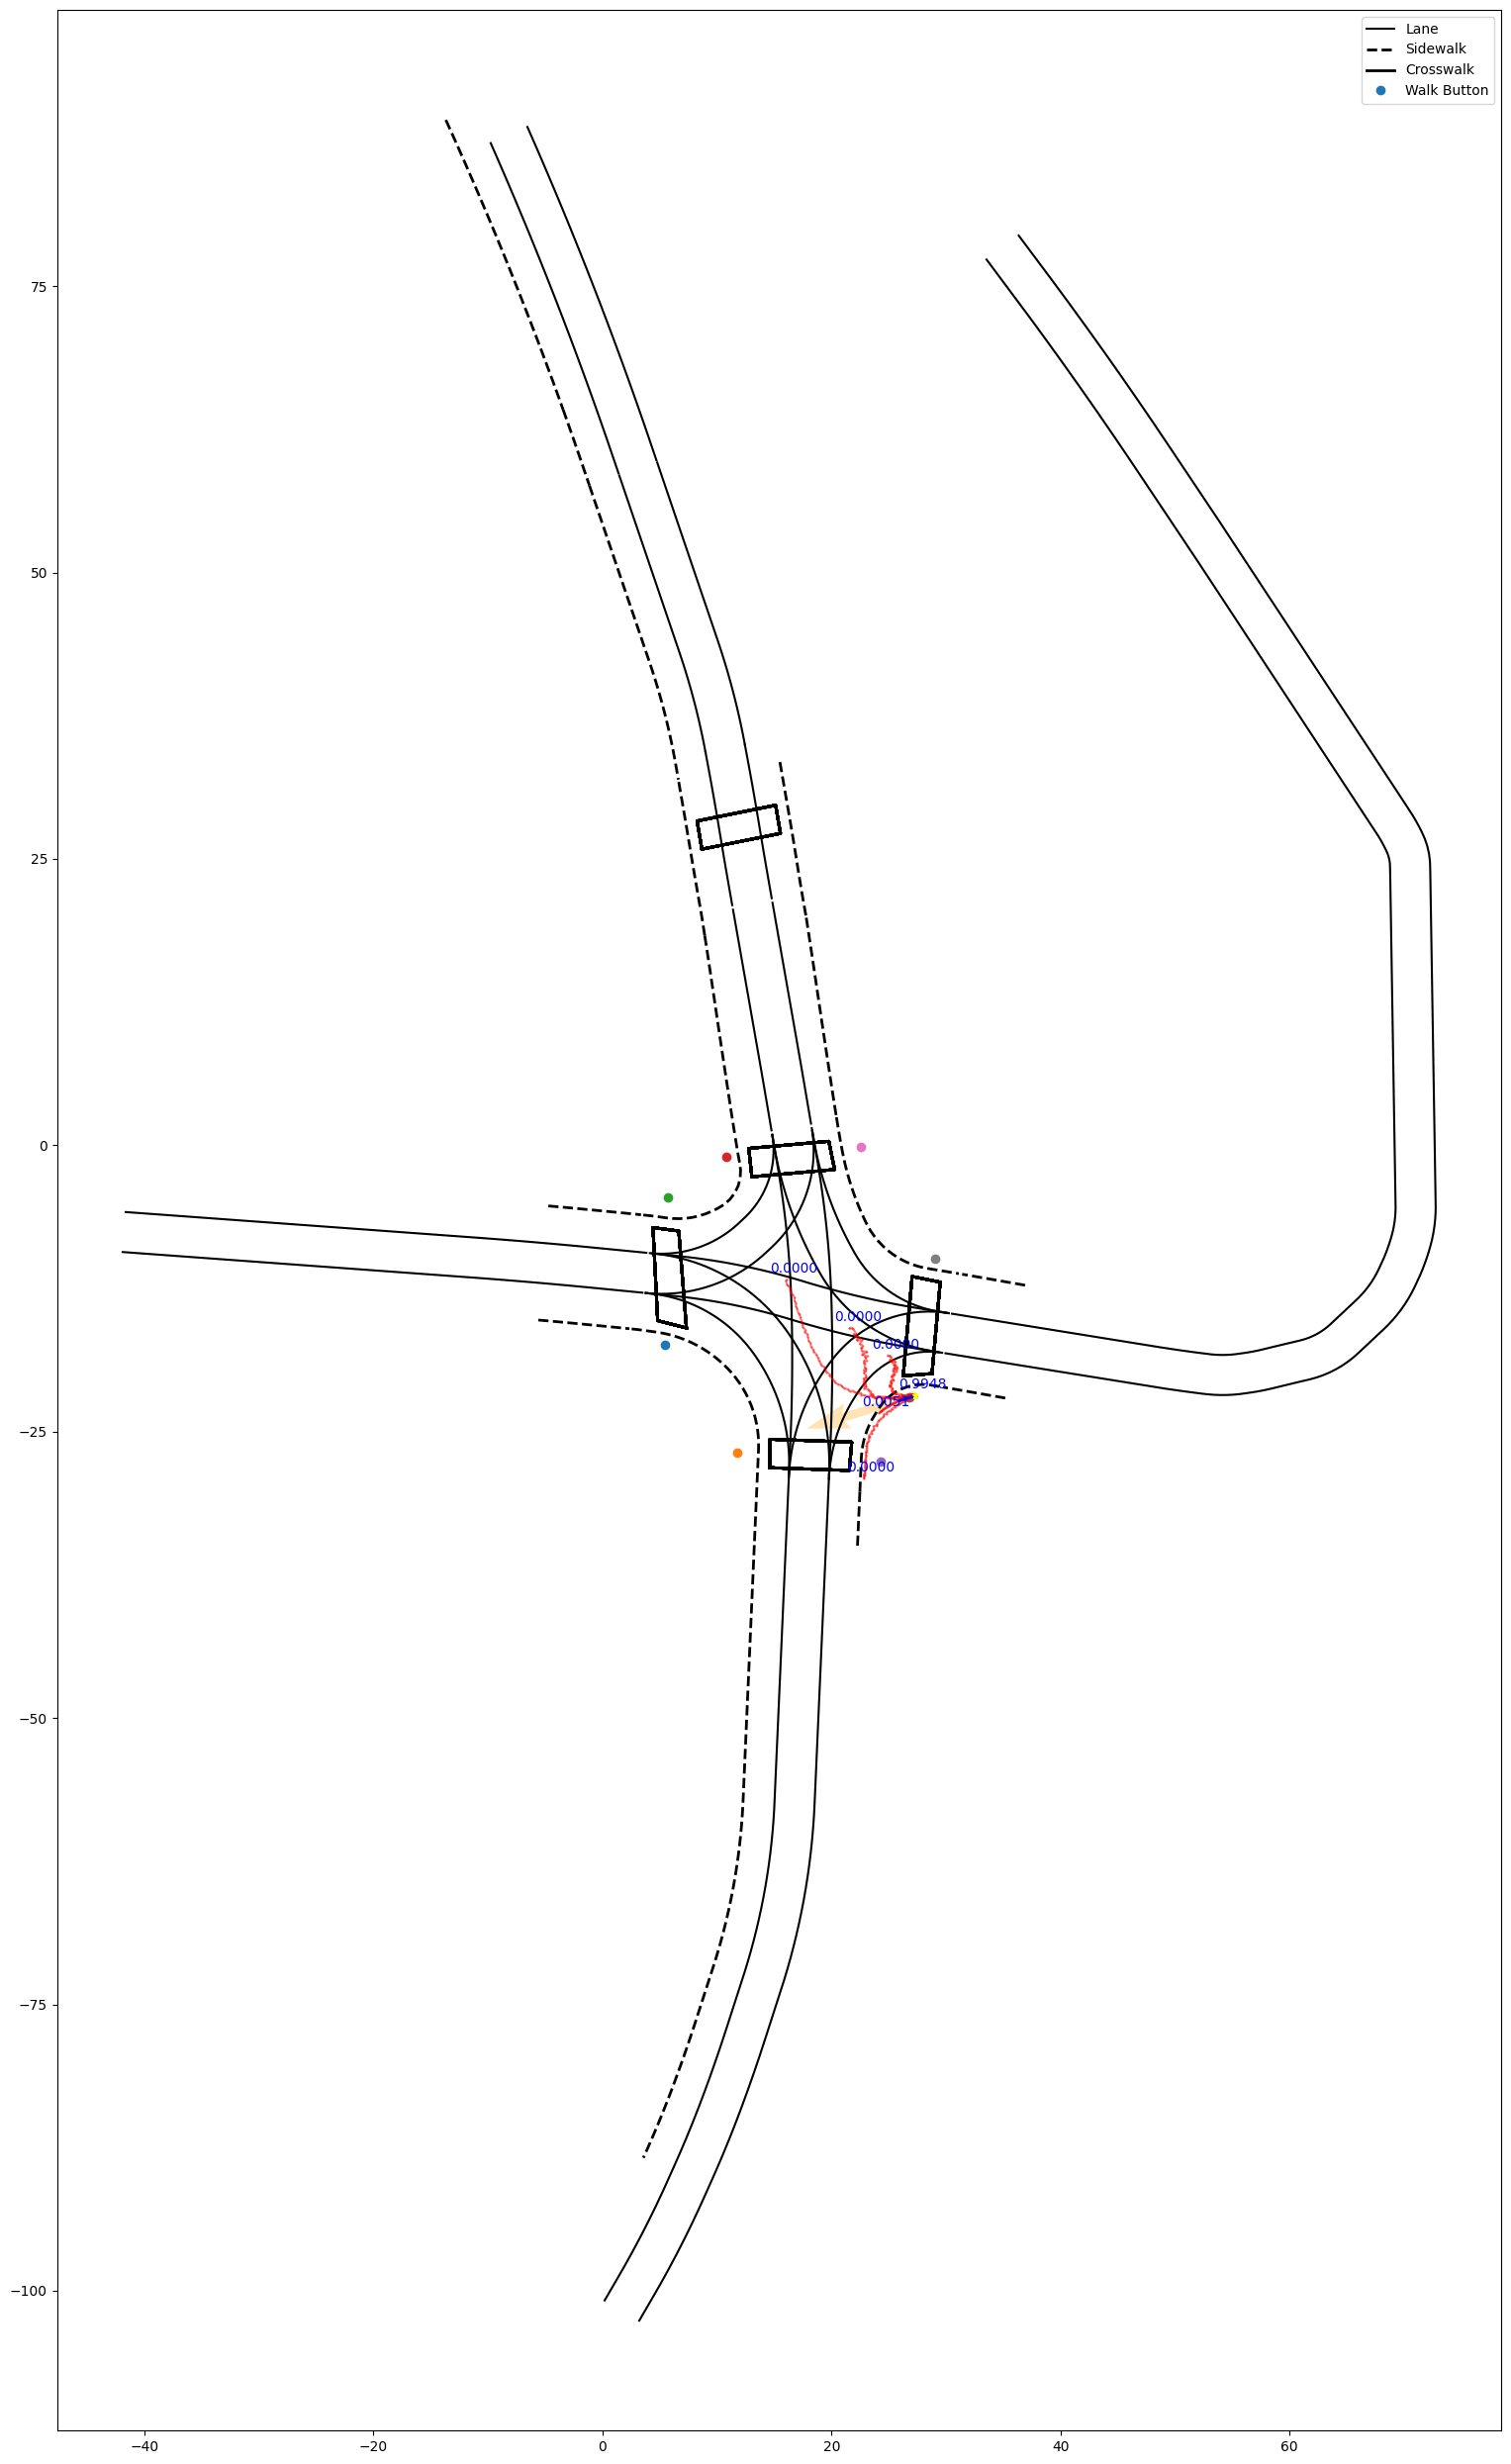

----------------------------------------------------


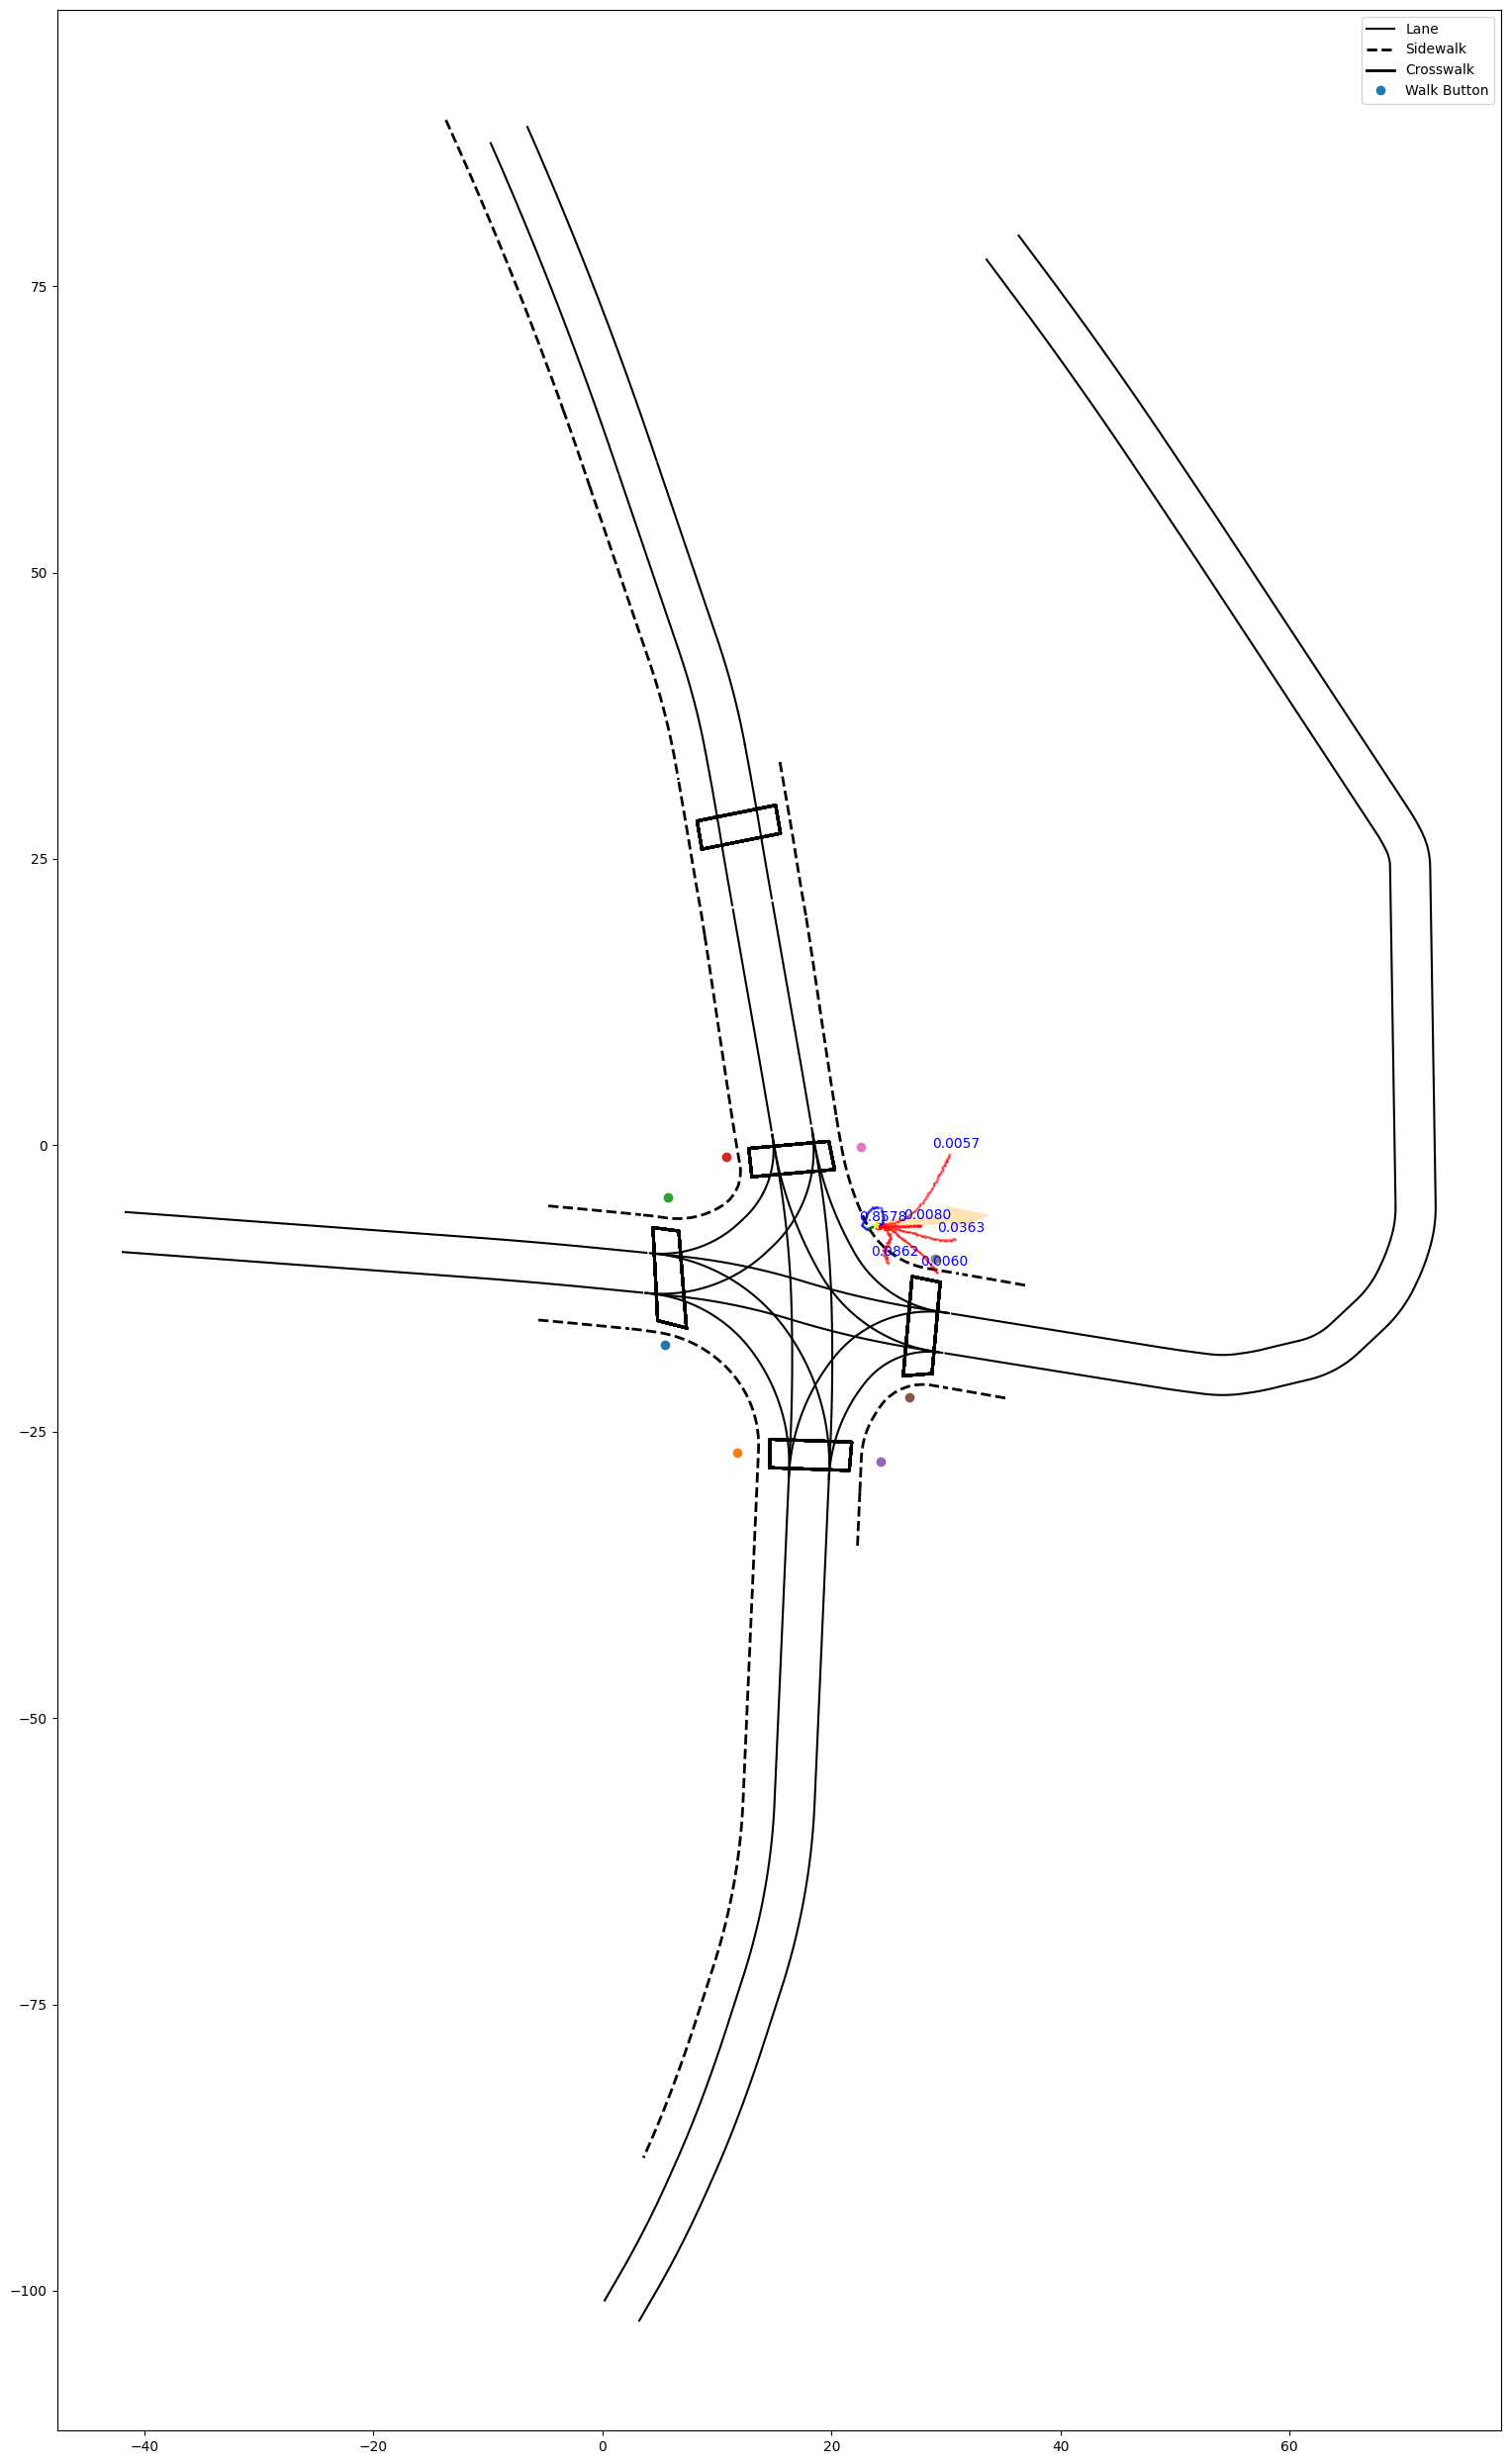

----------------------------------------------------


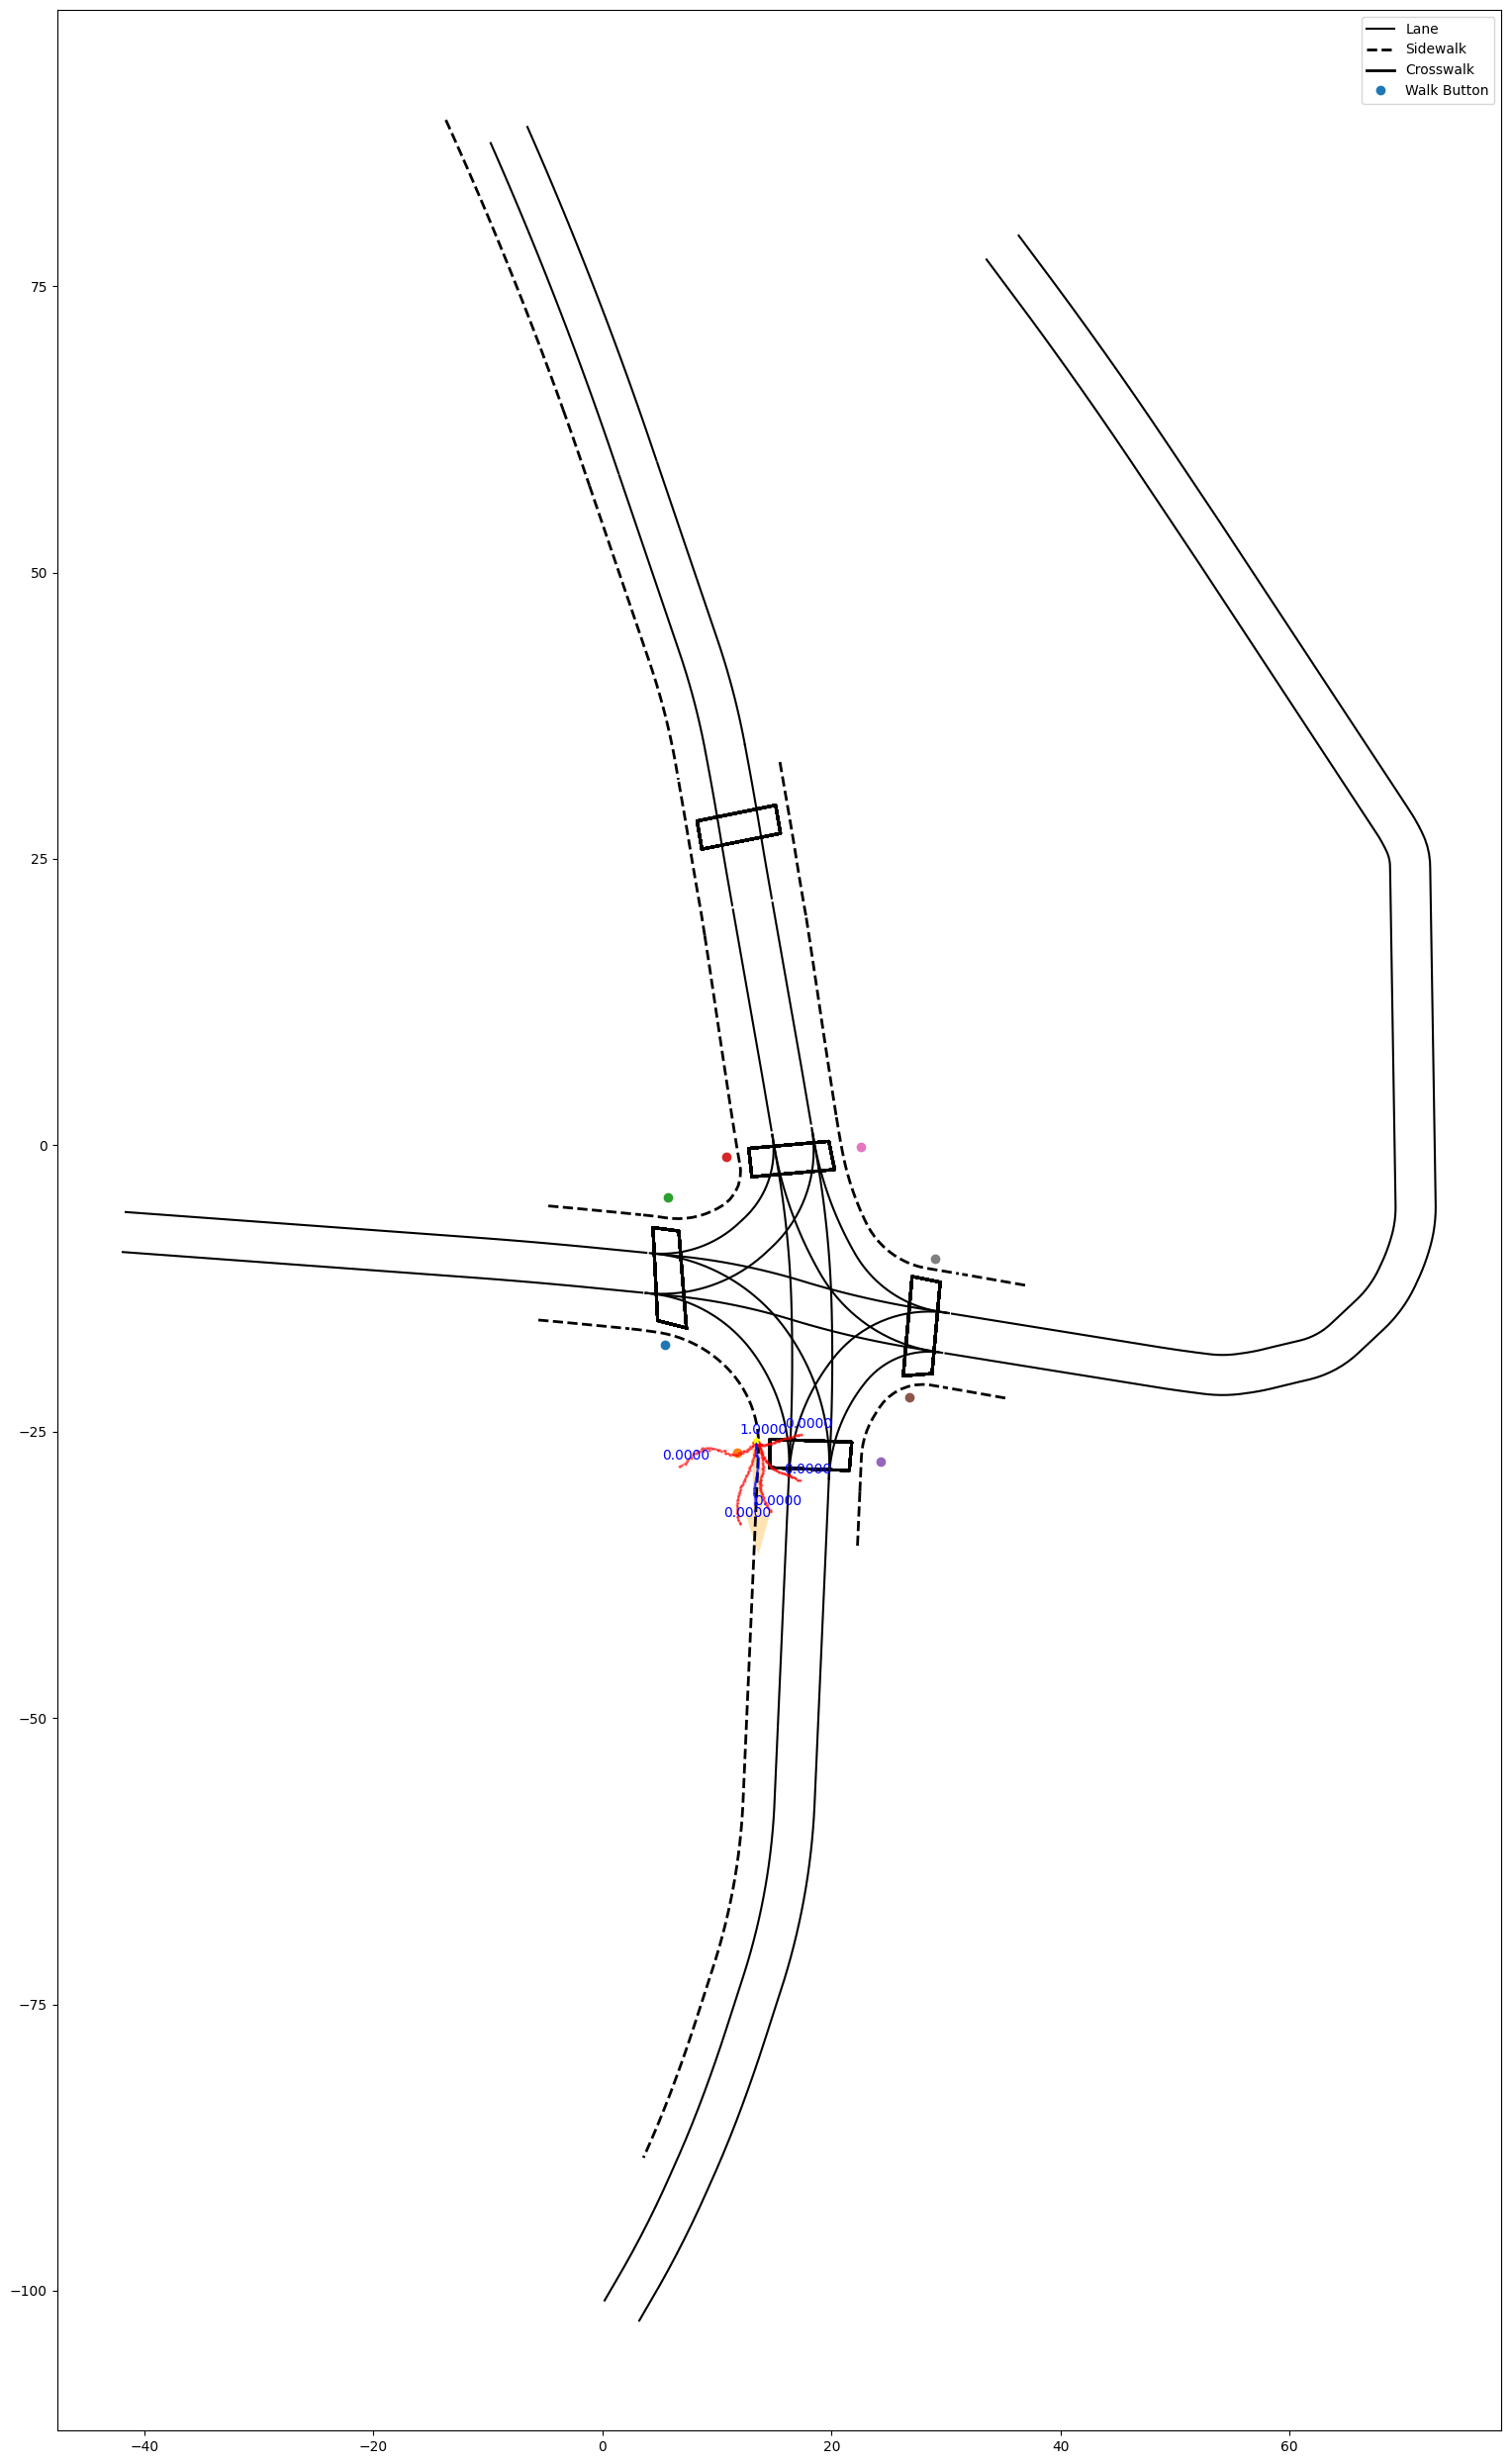

----------------------------------------------------


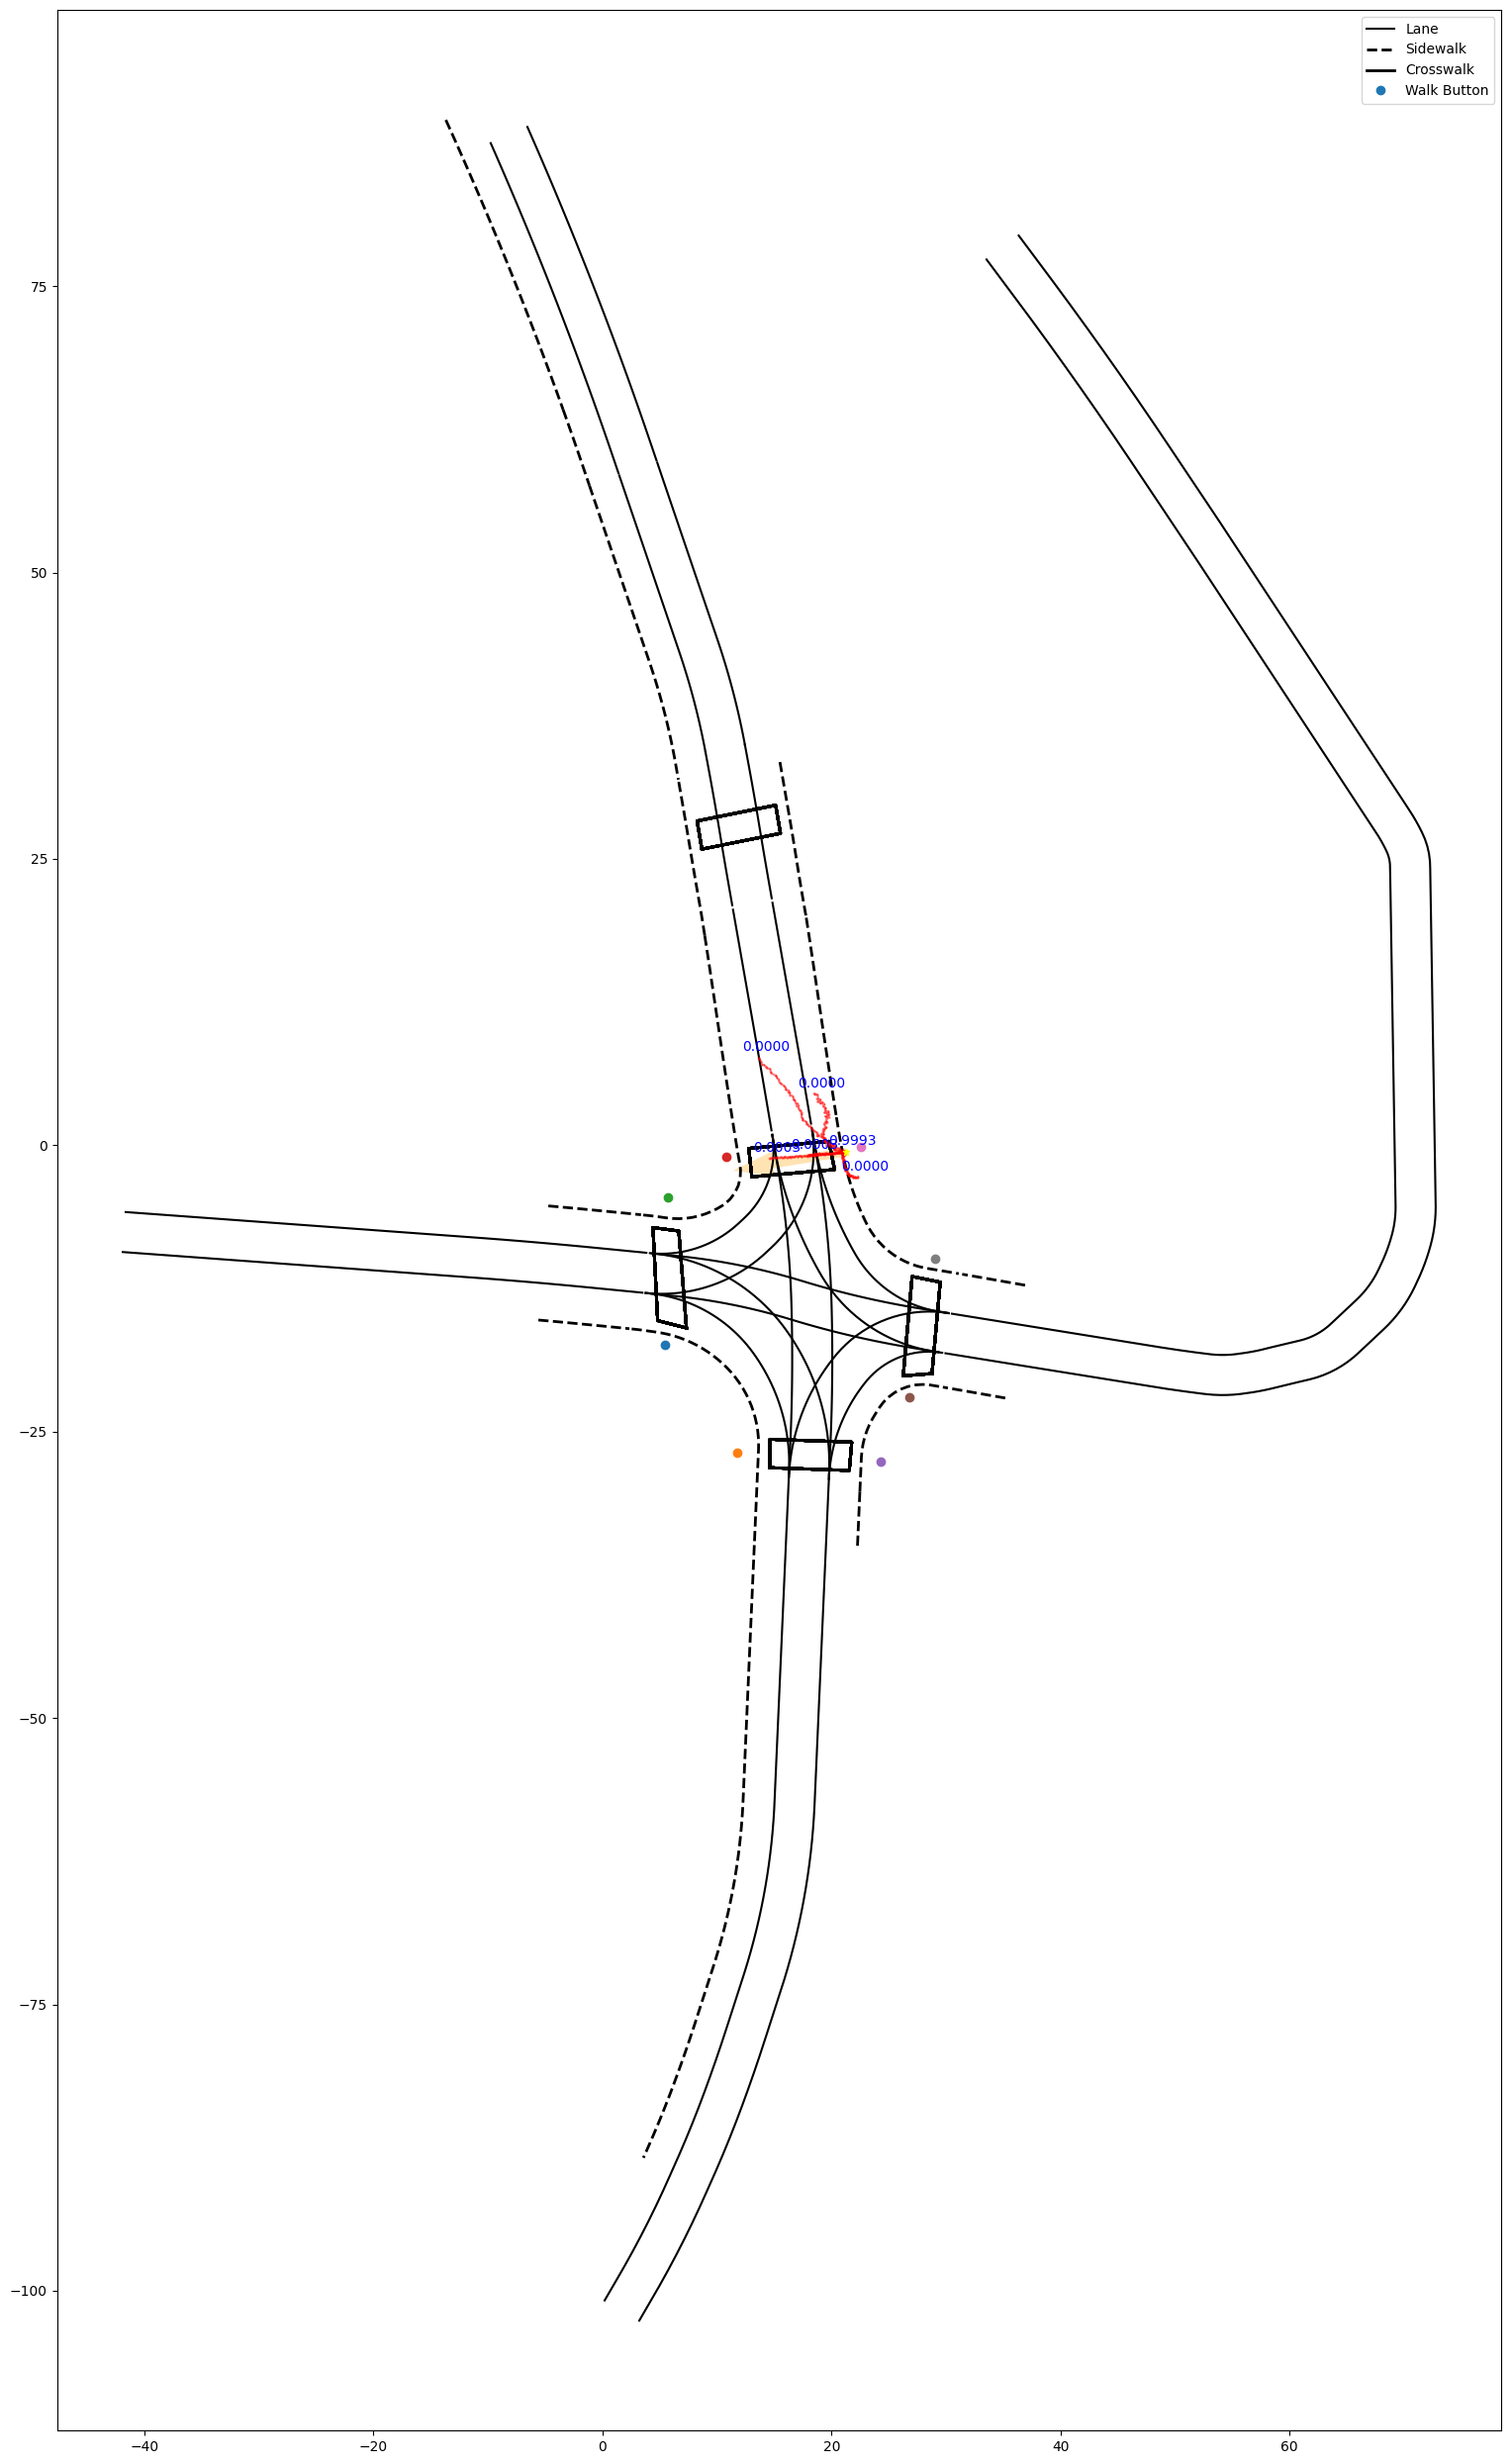

----------------------------------------------------


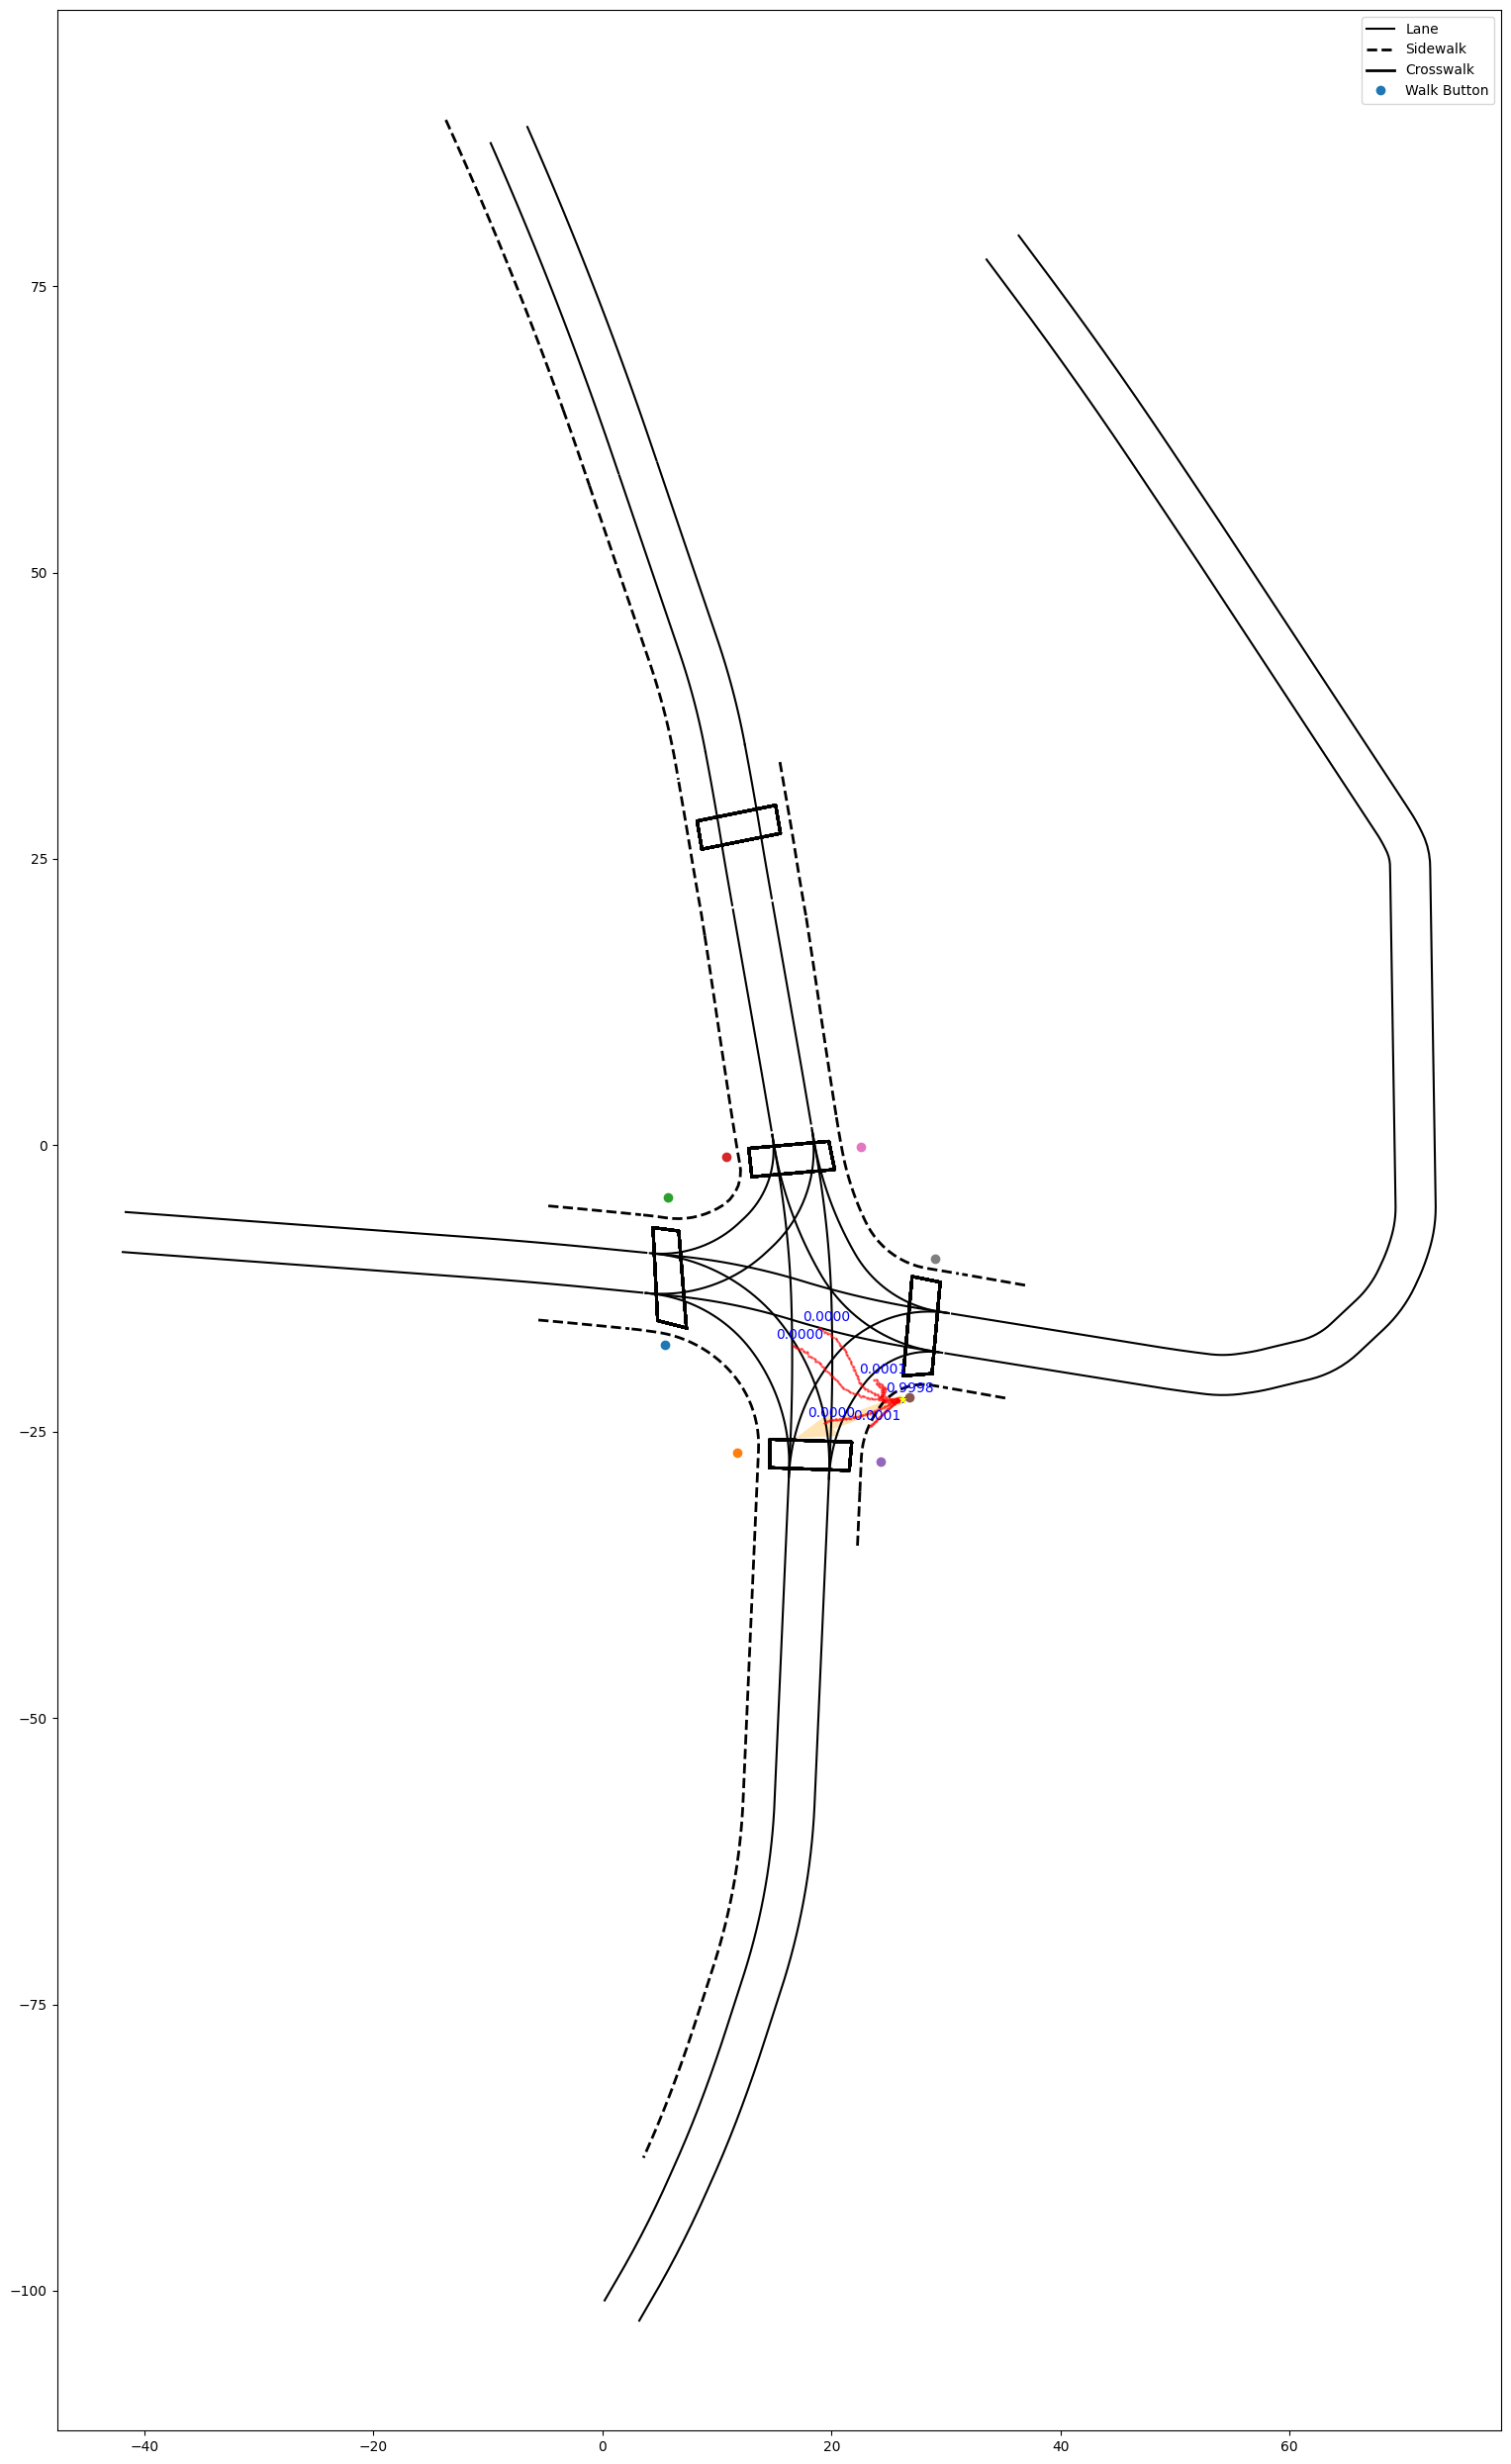

----------------------------------------------------


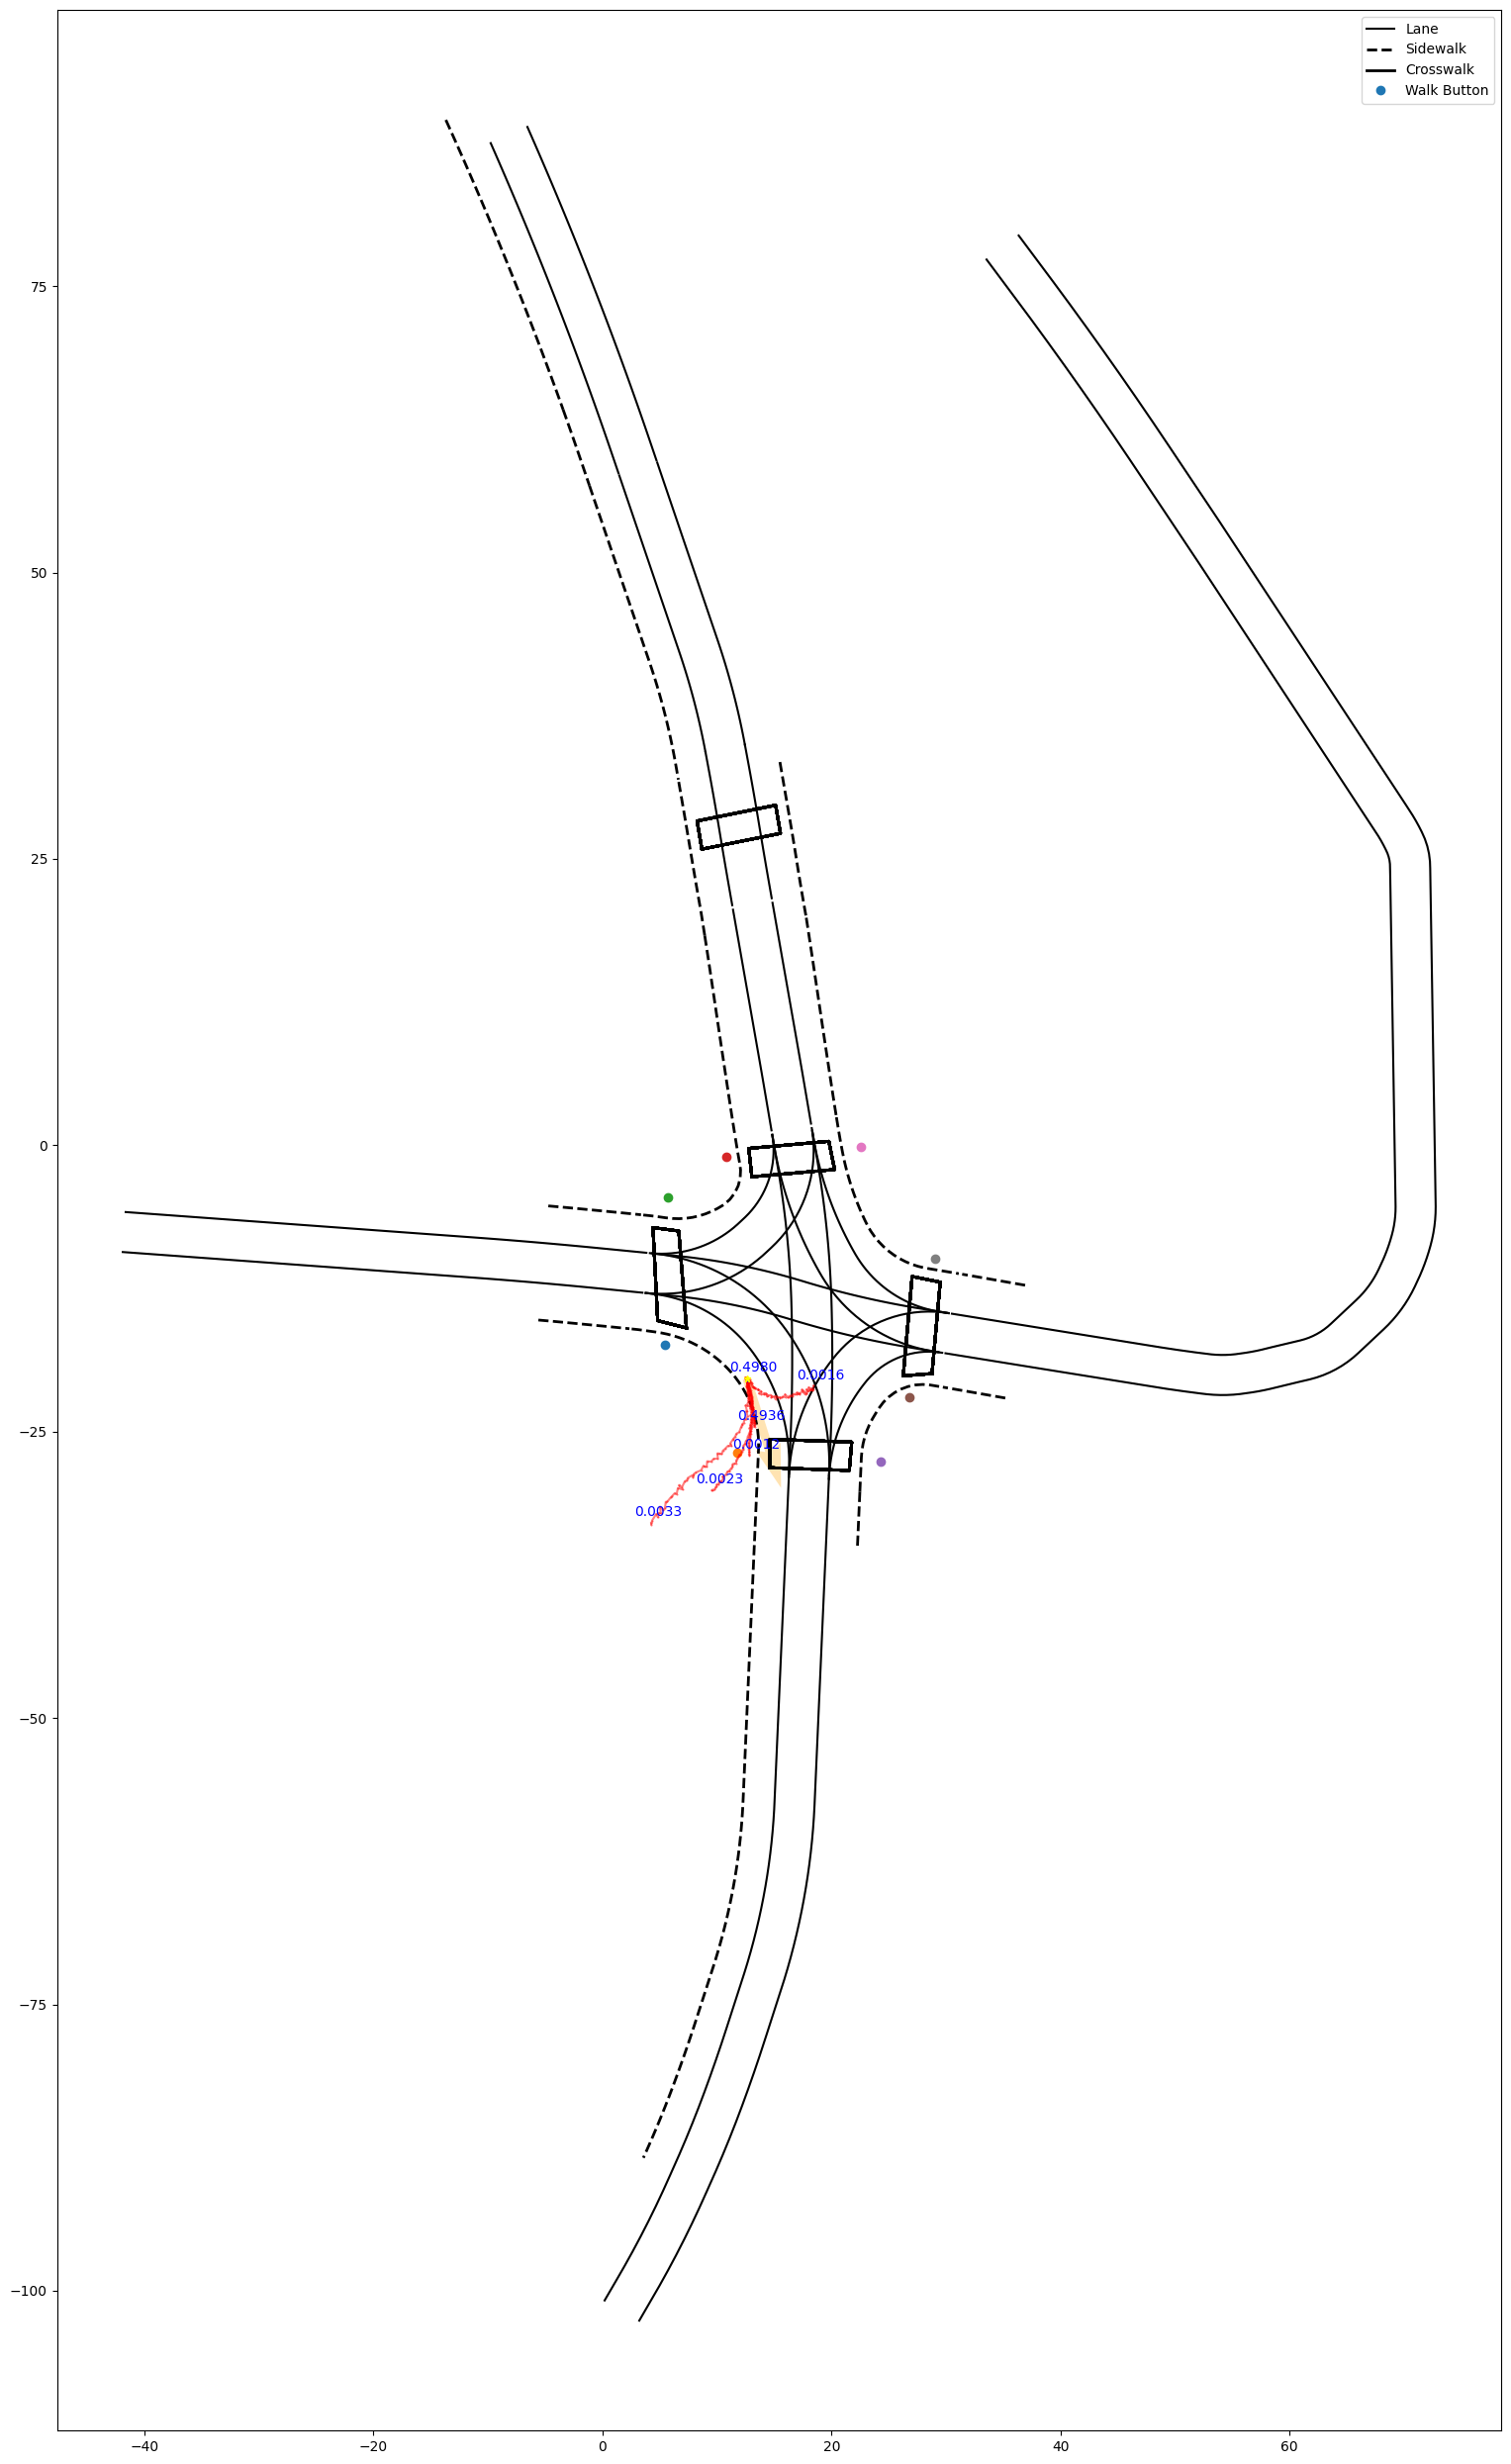

----------------------------------------------------


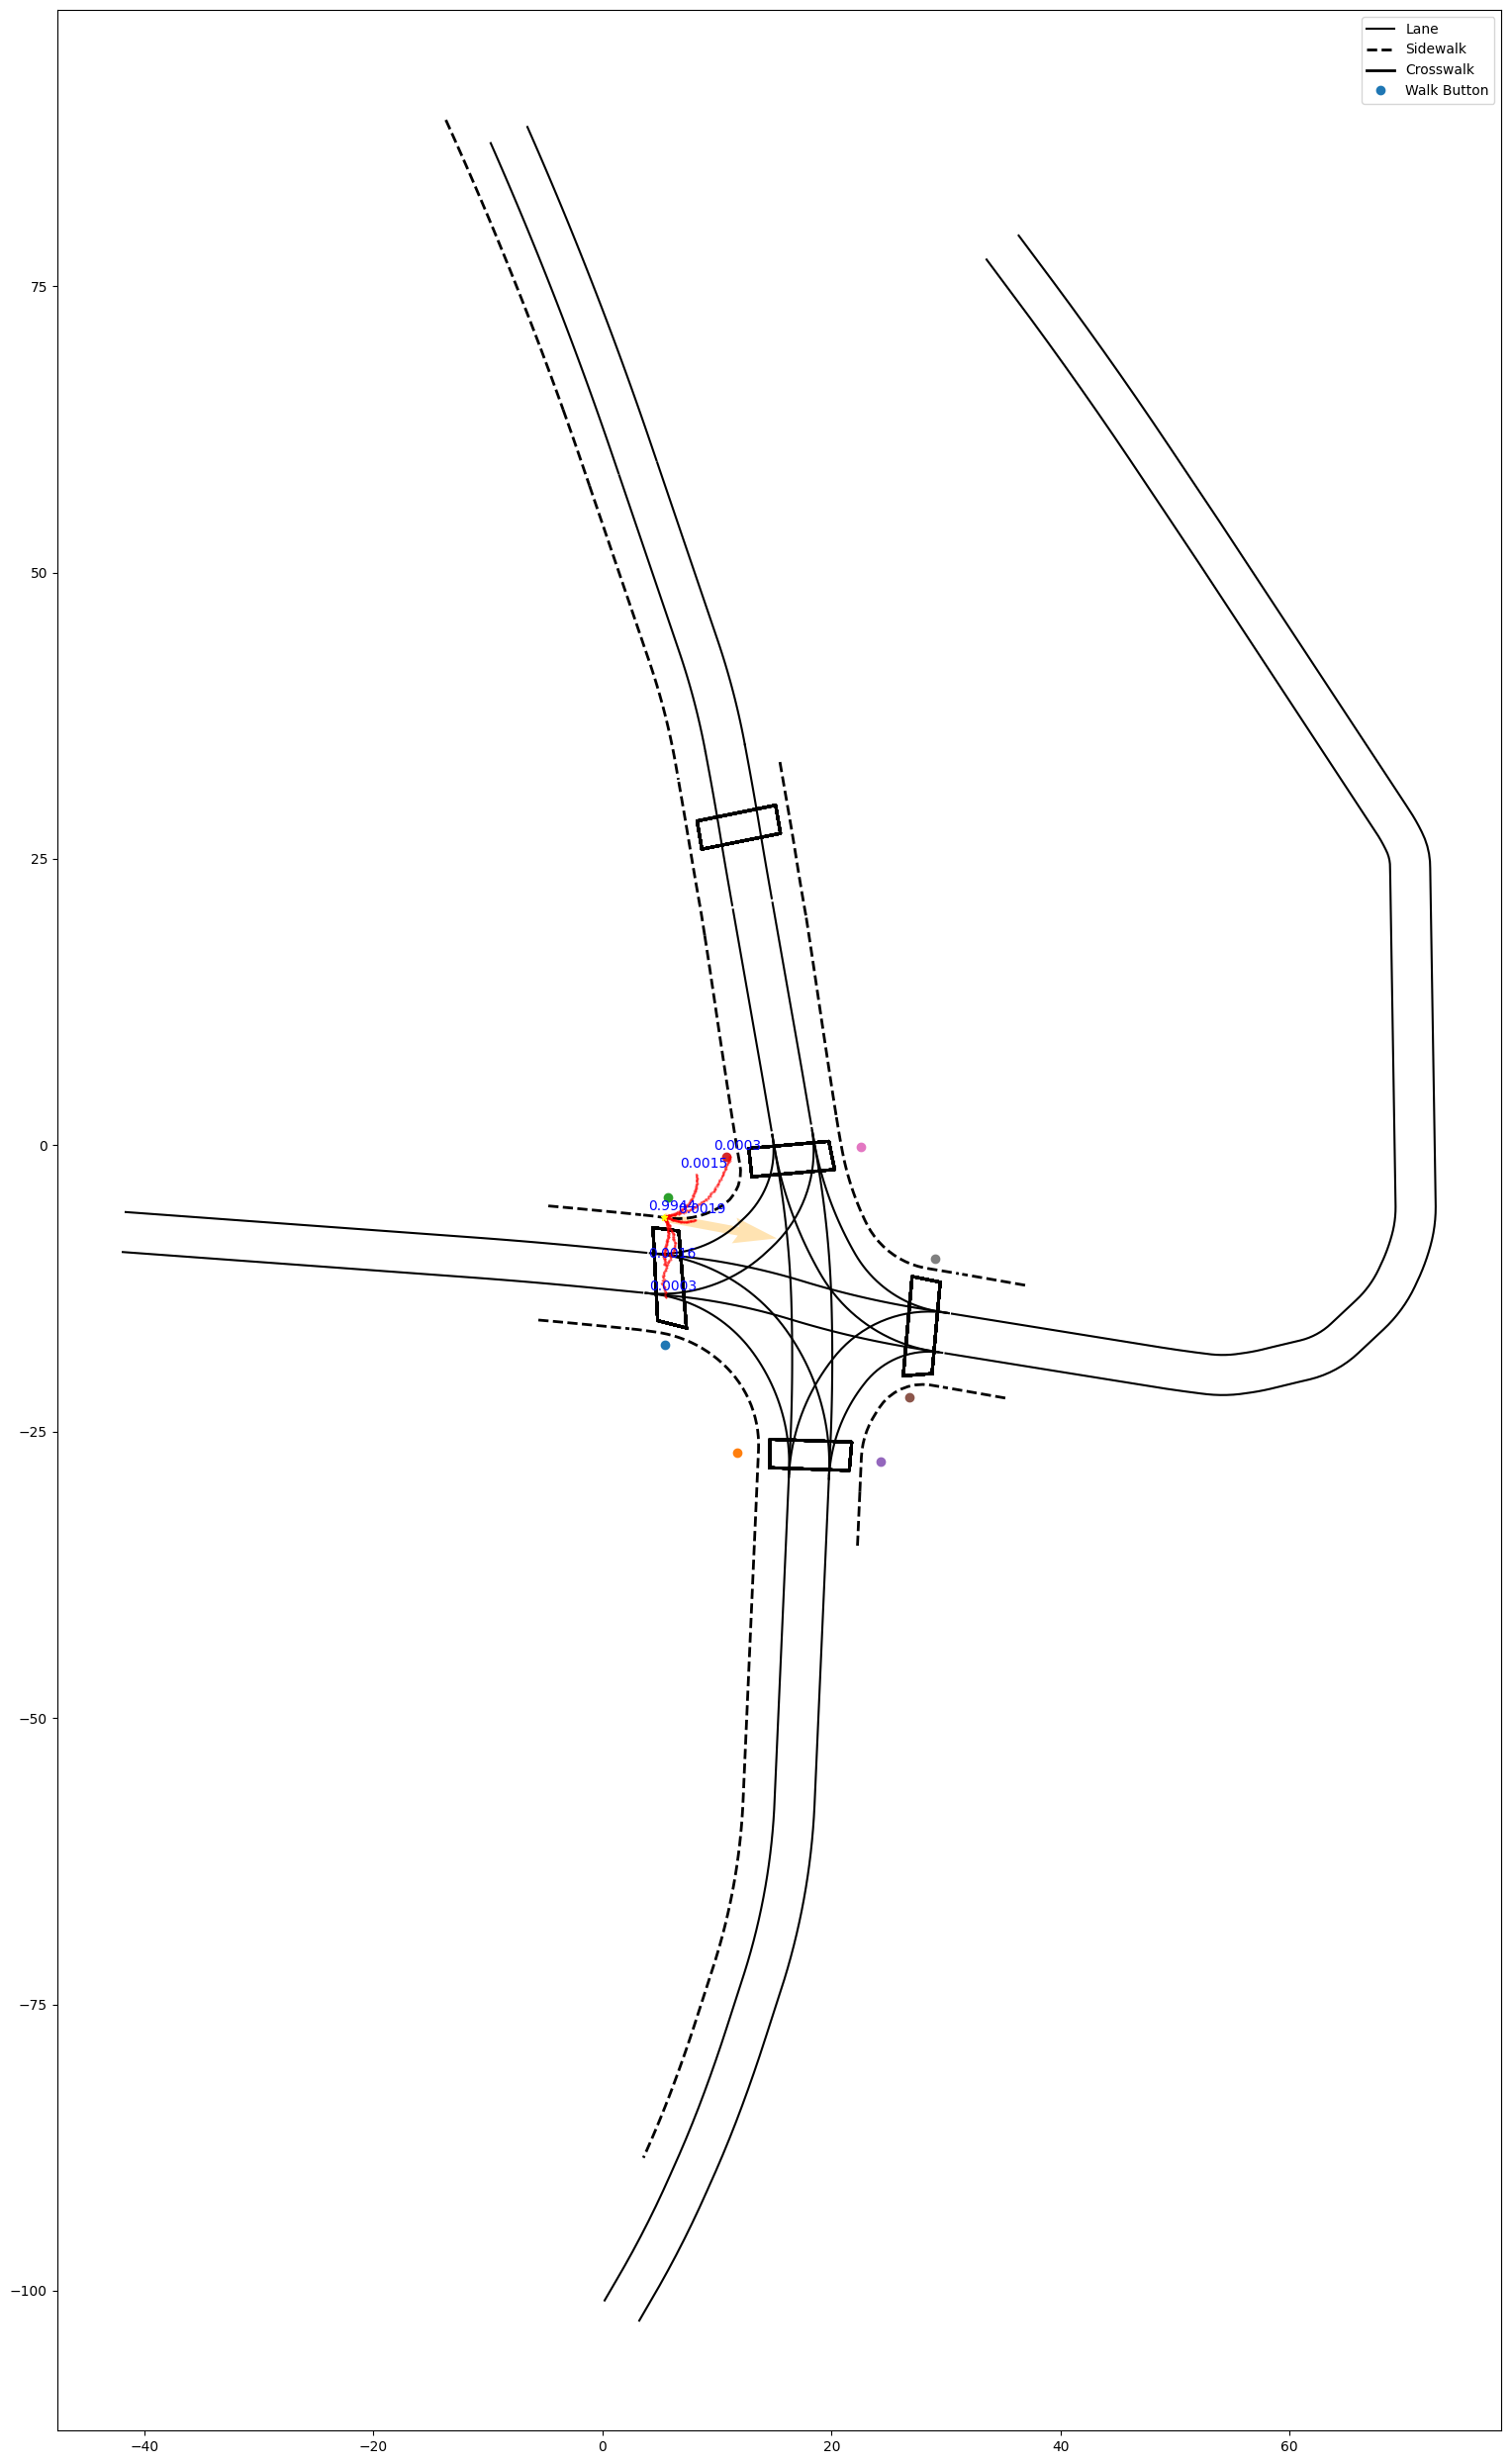

----------------------------------------------------


In [12]:
# plot VEHICLE traj output
k = 0
for i in range(len(val_ann_h1s_cluster32)):
    for j in range(len(val_ann_h1s_cluster32[i])):
        if val_ann_h1s_cluster32[i][j]['object_type'] == 'TYPE_PEDESTRIAN':
            plot_traj_withmap_withheading(i,j, val_ann12_h1s_cluster32,vector_map,6)
            print('----------------------------------------------------')
            k += 1
    if k >= 10:
        break

In [ ]:
# plot VEHICLE traj output
k = 0
for i in range(len(val_ann_h1s_cluster32)):
    for j in range(len(val_ann_h1s_cluster32[i])):
        if val_ann_h1s_cluster32[i][j]['object_type'] == 'TYPE_DUMMY':
            plot_traj_withmap_withheading(i,j, val_ann_h1s_cluster32,vector_map,6)
            print('----------------------------------------------------')
            k += 1
    if k >= 10:
        break

In [11]:
# plot VEHICLE traj output
k = 0
for i in range(len(derivheading_fromscratch)):
    for j in range(len(derivheading_fromscratch[i])):
        if derivheading_fromscratch[i][j]['object_type'] == 'TYPE_DUMMY':
            plot_traj_withmap_withheading(i,j, derivheading_fromscratch,vector_map,6)
            print('----------------------------------------------------')
            k += 1
    if k >= 5:
        break

In [ ]:
# plot PEDESTRIAN traj output
k = 0
for i in range(len(derivheading_fromscratch)):
    for j in range(len(derivheading_fromscratch[i])):
        if derivheading_fromscratch[i][j]['object_type'] == 'TYPE_PEDESTRIAN':
            plot_traj_withmap_withheading(i,j, derivheading_fromscratch,vector_map,6)
            print('----------------------------------------------------')
            k += 1
    if k >= 10:
        break

In [ ]:
# plot CYCLIST traj output
k = 0
for i in range(len(derivheading_fromscratch)):
    for j in range(len(derivheading_fromscratch[i])):
        if derivheading_fromscratch[i][j]['object_type'] == 'TYPE_CYCLIST':
            plot_traj_withmap_withheading(i,j, derivheading_fromscratch,vector_map,6)
            print('----------------------------------------------------')
            k += 1
    if k >= 10:
        break